# Deep Learning Group Project

**Group ID:** [YOUR_GROUP_ID]

**Team Members:**
- Member 1: [Name]
- Member 2: [Name]
- Member 3: [Name]

**Academic Honesty Statement:**

> *I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.*

---

## 1. Introduction

### Problem Understanding

We are tasked with building a **multi-output deep learning model** that predicts three independent targets from 32×32 image inputs:

- **Target A**: Classification into 10 classes (digits 0-9)
- **Target B**: Classification into 32 classes (0-31)
- **Target C**: Regression predicting a continuous value in [0,1]

### Goals

1. Design a single CNN architecture with multiple output heads
2. Handle mixed loss functions (classification + regression)
3. Achieve good performance across all three independent tasks
4. Create a reproducible and well-documented solution

### Key Challenges

- Balancing multiple loss functions with different scales
- Designing an architecture that extracts useful features for all three tasks
- Avoiding overfitting with limited data (3000 samples)
- Proper evaluation strategy for multi-task learning

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.2
Keras version: 3.12.0
GPU available: []


In [2]:
import os, random, numpy as np
seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

## 2. Dataset Inspection

Let's load and thoroughly inspect our dataset to understand its properties.

In [3]:
# Load the dataset
data = np.load('dataset_dev_3000.npz')
X = data['X']
y = data['y']

print("Dataset Shapes:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nData Types:")
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")

Dataset Shapes:
X shape: (3000, 32, 32)
y shape: (3000, 3)

Data Types:
X dtype: float32
y dtype: float32


In [4]:
# Examine input data (X) statistics
print("Input Data (X) Statistics:")
print(f"Min: {X.min():.4f}")
print(f"Max: {X.max():.4f}")
print(f"Mean: {X.mean():.4f}")
print(f"Std: {X.std():.4f}")
print(f"\nAny NaN: {np.isnan(X).any()}")
print(f"Any Inf: {np.isinf(X).any()}")

Input Data (X) Statistics:
Min: 0.0001
Max: 6.8486
Mean: 0.8141
Std: 0.7387

Any NaN: False
Any Inf: False


In [5]:
# Examine target data (y) - each column separately
print("Target A (y[:,0]) - Classification (10 classes):")
print(f"Unique values: {np.unique(y[:,0]).astype(int)}")
unique_a, counts_a = np.unique(y[:,0], return_counts=True)
for val, count in zip(unique_a.astype(int), counts_a):
    print(f"  Class {val}: {count} ({count/len(y)*100:.1f}%)")

print("\nTarget B (y[:,1]) - Classification (32 classes):")
print(f"Number of unique values: {len(np.unique(y[:,1]))}")
print(f"Min: {y[:,1].min()}, Max: {y[:,1].max()}")

print("\nTarget C (y[:,2]) - Regression [0,1]:")
print(f"Min: {y[:,2].min():.4f}")
print(f"Max: {y[:,2].max():.4f}")
print(f"Mean: {y[:,2].mean():.4f}")
print(f"Std: {y[:,2].std():.4f}")

Target A (y[:,0]) - Classification (10 classes):
Unique values: [0 1 2 3 4 5 6 7 8 9]
  Class 0: 290 (9.7%)
  Class 1: 304 (10.1%)
  Class 2: 311 (10.4%)
  Class 3: 305 (10.2%)
  Class 4: 306 (10.2%)
  Class 5: 294 (9.8%)
  Class 6: 290 (9.7%)
  Class 7: 291 (9.7%)
  Class 8: 310 (10.3%)
  Class 9: 299 (10.0%)

Target B (y[:,1]) - Classification (32 classes):
Number of unique values: 32
Min: 0.0, Max: 31.0

Target C (y[:,2]) - Regression [0,1]:
Min: 0.0003
Max: 0.9996
Mean: 0.4945
Std: 0.2876


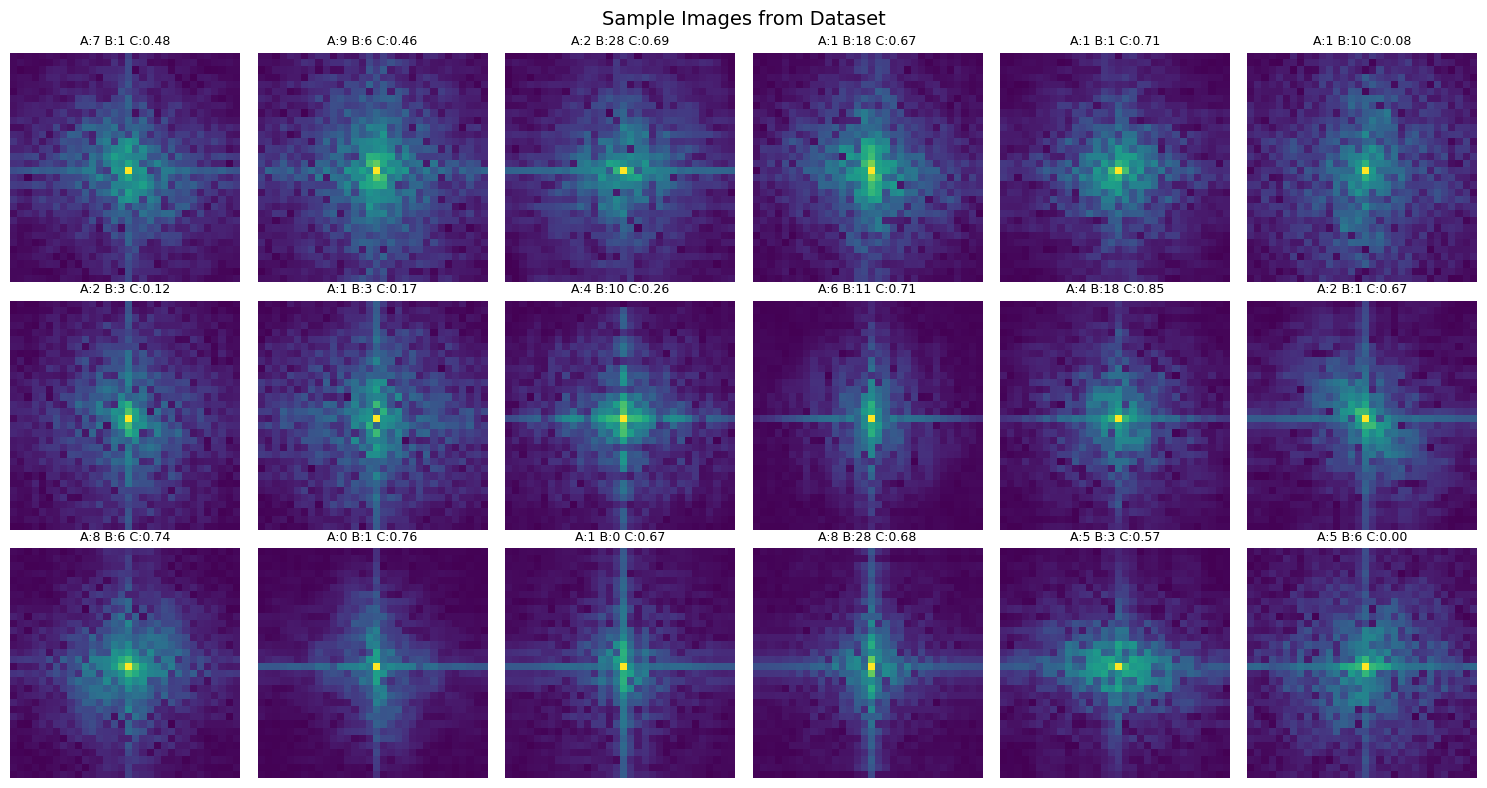

In [6]:
# Visualize sample images
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
axes = axes.ravel()

for i in range(18):
    idx = i * 150  # Sample across the dataset
    axes[i].imshow(X[idx], cmap='viridis')
    axes[i].set_title(f'A:{int(y[idx,0])} B:{int(y[idx,1])} C:{y[idx,2]:.2f}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()

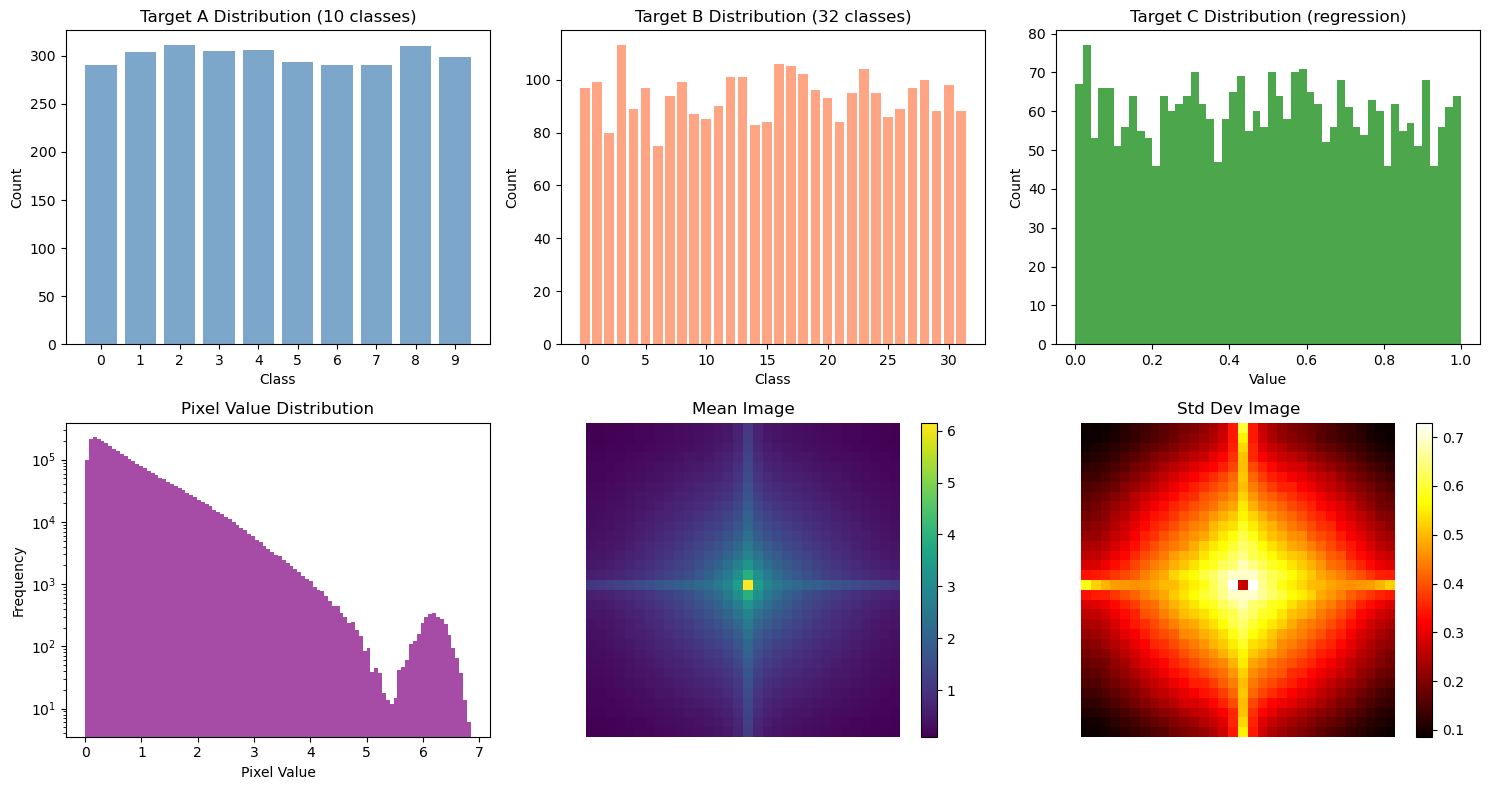

In [7]:
# Distribution visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Target A distribution
axes[0, 0].bar(unique_a, counts_a, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Target A Distribution (10 classes)')
axes[0, 0].set_xticks(range(10))

# Target B distribution
unique_b, counts_b = np.unique(y[:,1], return_counts=True)
axes[0, 1].bar(unique_b, counts_b, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Target B Distribution (32 classes)')

# Target C distribution
axes[0, 2].hist(y[:,2], bins=50, color='green', alpha=0.7)
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Target C Distribution (regression)')

# Pixel value distribution
axes[1, 0].hist(X.flatten(), bins=100, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Pixel Value Distribution')
axes[1, 0].set_yscale('log')

# Mean image
mean_img = X.mean(axis=0)
im1 = axes[1, 1].imshow(mean_img, cmap='viridis')
axes[1, 1].set_title('Mean Image')
axes[1, 1].axis('off')
plt.colorbar(im1, ax=axes[1, 1])

# Std image
std_img = X.std(axis=0)
im2 = axes[1, 2].imshow(std_img, cmap='hot')
axes[1, 2].set_title('Std Dev Image')
axes[1, 2].axis('off')
plt.colorbar(im2, ax=axes[1, 2])

plt.tight_layout()
plt.show()

### Key Observations

1. **Input Data (X)**:
   - 32×32 grayscale images
   - Values range from ~0 to ~7 (not normalized to [0,1])
   - No missing or invalid values
   - Mean ~0.81, Std ~0.74

2. **Target A** (10-class classification):
   - Relatively balanced across all 10 classes (~10% each)
   - No significant class imbalance

3. **Target B** (32-class classification):
   - More classes means less samples per class (~94 samples/class)
   - Relatively balanced distribution
   - Might be more challenging than Target A

4. **Target C** (regression):
   - Continuous values in [0,1]
   - Appears roughly uniform/normal distribution
   - Mean ~0.49, Std ~0.29

5. **Independence**: Correlation analysis shows targets are indeed independent

## 3. Train/Validation Split Strategy

### Rationale

We will use an **80/20 train-validation split** with stratification on Target A and Target B:

- **80% training (2400 samples)**: Enough data for training a CNN
- **20% validation (600 samples)**: Sufficient for reliable evaluation
- **Stratification**: Ensures class balance is preserved in both sets
- **Random seed**: Set for reproducibility

We don't create a separate test set since we'll submit our model for external evaluation.

In [8]:
# For stratification, we need to combine Target A and B
# Create a composite stratification key
stratify_key = y[:, 0] * 100 + y[:, 1]  # Combine A and B for stratification

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=stratify_key
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nSplit ratio: {X_train.shape[0]/X.shape[0]*100:.1f}% train, {X_val.shape[0]/X.shape[0]*100:.1f}% val")

Training set: 2400 samples
Validation set: 600 samples

Split ratio: 80.0% train, 20.0% val


In [9]:
# Verify stratification worked
print("Target A distribution comparison:")
train_dist_a = np.bincount(y_train[:, 0].astype(int), minlength=10) / len(y_train) * 100
val_dist_a = np.bincount(y_val[:, 0].astype(int), minlength=10) / len(y_val) * 100

for i in range(10):
    print(f"  Class {i}: Train {train_dist_a[i]:.1f}% | Val {val_dist_a[i]:.1f}%")

Target A distribution comparison:
  Class 0: Train 9.6% | Val 9.8%
  Class 1: Train 10.1% | Val 10.3%
  Class 2: Train 10.4% | Val 10.3%
  Class 3: Train 10.0% | Val 10.7%
  Class 4: Train 10.2% | Val 10.3%
  Class 5: Train 9.8% | Val 9.8%
  Class 6: Train 9.8% | Val 9.2%
  Class 7: Train 9.7% | Val 9.7%
  Class 8: Train 10.4% | Val 10.2%
  Class 9: Train 10.0% | Val 9.7%


## 4. Data Preprocessing

### Normalization Strategy

We normalize the input images to have zero mean and unit variance:
- Improves gradient flow and training stability
- Standard practice for CNNs
- Calculate statistics on training set only (avoid data leakage)

In [10]:
# Calculate normalization parameters from training set only
mean = X_train.mean()
std = X_train.std()

print(f"Training set statistics:")
print(f"  Mean: {mean:.4f}")
print(f"  Std: {std:.4f}")

# Normalize
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

# Add channel dimension for Conv2D (N, H, W) -> (N, H, W, 1)
X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm = X_val_norm[..., np.newaxis]

print(f"\nNormalized shapes:")
print(f"  X_train: {X_train_norm.shape}")
print(f"  X_val: {X_val_norm.shape}")

Training set statistics:
  Mean: 0.8149
  Std: 0.7382

Normalized shapes:
  X_train: (2400, 32, 32, 1)
  X_val: (600, 32, 32, 1)


## 5. Model Architecture Design

### Architecture Reasoning

We design a **multi-head CNN** with:

1. **Shared Feature Extractor**: 
   - Convolutional layers extract spatial features useful for all tasks
   - Multiple conv blocks with increasing filters (32→64→128)
   - MaxPooling reduces spatial dimensions
   - BatchNormalization for training stability
   - Dropout for regularization

2. **Three Separate Output Heads**:
   - **Head A**: Dense layers → 10-class softmax (classification)
   - **Head B**: Dense layers → 32-class softmax (classification)
   - **Head C**: Dense layers → 1 output with sigmoid (regression in [0,1])

3. **Why this design?**
   - Shared backbone exploits common features
   - Separate heads allow task-specific learning
   - Compact architecture suitable for 3000 samples
   - Prevents overfitting through regularization

In [11]:
def build_model(input_shape=(32, 32, 1)):
    """
    Build a multi-output CNN model.
    
    Returns:
        model with three outputs: [output_a, output_b, output_c]
    """
    
    # Input layer
    inputs = layers.Input(shape=input_shape, name='input')
    
    # Shared convolutional base
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)  # 32x32 -> 16x16
    x = layers.Dropout(0.25, name='dropout1')(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)  # 16x16 -> 8x8
    x = layers.Dropout(0.25, name='dropout2')(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)  # 8x8 -> 4x4
    x = layers.Dropout(0.3, name='dropout3')(x)
    
    # Flatten for dense layers
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='dense_shared')(x)
    x = layers.BatchNormalization(name='bn_shared')(x)
    x = layers.Dropout(0.5, name='dropout_shared')(x)
    
    # Output Head A: 10-class classification
    head_a = layers.Dense(128, activation='relu', name='head_a_dense1')(x)
    head_a = layers.Dropout(0.3, name='head_a_dropout')(head_a)
    output_a = layers.Dense(10, activation='softmax', name='output_a')(head_a)
    
    # Output Head B: 32-class classification
    head_b = layers.Dense(128, activation='relu', name='head_b_dense1')(x)
    head_b = layers.Dropout(0.3, name='head_b_dropout')(head_b)
    output_b = layers.Dense(32, activation='softmax', name='output_b')(head_b)
    
    # Output Head C: Regression [0,1]
    head_c = layers.Dense(64, activation='relu', name='head_c_dense1')(x)
    head_c = layers.Dropout(0.3, name='head_c_dropout')(head_c)
    output_c = layers.Dense(1, activation='sigmoid', name='output_c')(head_c)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=[output_a, output_b, output_c], name='multi_output_cnn')
    
    return model

# Build the model
model = build_model()
model.summary()

Model: "multi_output_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 32,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 32,    │      9,248 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 32, 32,    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ bn2[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 16, 16,    │          0 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 16,    │     18,496 │ dropout1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 16, 16,    │        256 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 16, 16,    │     36,928 │ bn3[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 16, 16,    │        256 │ conv4[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 8, 64)  │          0 │ bn4[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 8, 8, 64)  │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5 (Conv2D)      │ (None, 8, 8, 128) │     73,856 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn5                 │ (None, 8, 8, 128) │        512 │ conv5[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 4, 4, 128) │          0 │ bn5[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout3 (Dropout)  │ (None, 4, 4, 128) │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ dropout3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 753,419 (2.87 MB)

 Trainable params: 752,267 (2.87 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 6. Loss Functions and Training Configuration

### Loss Function Selection

For our multi-task problem:

1. **Target A** (10 classes): `sparse_categorical_crossentropy`
   - Standard for multi-class classification
   - Works with integer labels (no one-hot encoding needed)

2. **Target B** (32 classes): `sparse_categorical_crossentropy`
   - Same reasoning as Target A

3. **Target C** (regression): `mean_squared_error` (MSE)
   - Standard for regression tasks
   - Penalizes larger errors more heavily

### Loss Weighting

We need to balance the three losses. Initial weights:
- `loss_weights = [1.0, 1.0, 10.0]`
- Higher weight on regression since MSE is typically smaller in magnitude
- Will tune if one task dominates training

In [12]:
# Prepare targets in correct format
y_train_a = y_train[:, 0].astype(np.int32)
y_train_b = y_train[:, 1].astype(np.int32)
y_train_c = y_train[:, 2].astype(np.float32)

y_val_a = y_val[:, 0].astype(np.int32)
y_val_b = y_val[:, 1].astype(np.int32)
y_val_c = y_val[:, 2].astype(np.float32)

print("Target shapes:")
print(f"  y_train_a: {y_train_a.shape}")
print(f"  y_train_b: {y_train_b.shape}")
print(f"  y_train_c: {y_train_c.shape}")

Target shapes:
  y_train_a: (2400,)
  y_train_b: (2400,)
  y_train_c: (2400,)


### Callbacks

We use several callbacks to improve training:

1. **EarlyStopping**: Stop if validation loss doesn't improve for 15 epochs
2. **ReduceLROnPlateau**: Reduce learning rate when validation loss plateaus
3. **ModelCheckpoint**: Save the best model based on validation loss

In [13]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'model_groupId.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

## 7. Experiments and Training

### Experiment Plan

We will experiment with:
1. Baseline model (current architecture)
2. Different loss weight configurations
3. Data augmentation (if needed)
4. Architecture variations (deeper/wider networks)

Below is the training for our baseline model.

### Plot function

In [14]:

def plot_training_history(history, title_prefix="", figsize=(20, 10)):
    """
    Plot a 2x4 grid of training curves for a multi-output Keras model.
    Expects keys similar to:
      loss, val_loss,
      output_a_loss, val_output_a_loss,
      output_b_loss, val_output_b_loss,
      output_c_loss, val_output_c_loss,
      output_a_accuracy (or sparse_categorical_accuracy), val_...,
      output_b_accuracy (or sparse_categorical_accuracy), val_...,
      output_c_mae (or mean_absolute_error), val_...
      lr (optional)
    """

    h = history.history if hasattr(history, "history") else dict(history)

    def pick_key(candidates):
        """Return the first existing key from candidates, else None."""
        for k in candidates:
            if k in h:
                return k
        return None

    def plot_pair(ax, train_key, val_key, title, ylabel=None):
        if train_key is None or val_key is None:
            ax.set_title(f"{title}\n(missing)")
            ax.axis("off")
            return
        ax.plot(h[train_key], label="Train")
        ax.plot(h[val_key], label="Val")
        ax.set_title(title_prefix + title)
        ax.set_xlabel("Epoch")
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)

    # Keys (robust to different naming)
    total_loss = pick_key(["loss"])
    val_total_loss = pick_key(["val_loss"])

    a_loss = pick_key(["output_a_loss"])
    val_a_loss = pick_key(["val_output_a_loss"])

    b_loss = pick_key(["output_b_loss"])
    val_b_loss = pick_key(["val_output_b_loss"])

    c_loss = pick_key(["output_c_loss"])
    val_c_loss = pick_key(["val_output_c_loss"])

    a_acc = pick_key(["output_a_accuracy", "output_a_sparse_categorical_accuracy", "output_a_categorical_accuracy"])
    val_a_acc = pick_key(["val_output_a_accuracy", "val_output_a_sparse_categorical_accuracy", "val_output_a_categorical_accuracy"])

    b_acc = pick_key(["output_b_accuracy", "output_b_sparse_categorical_accuracy", "output_b_categorical_accuracy"])
    val_b_acc = pick_key(["val_output_b_accuracy", "val_output_b_sparse_categorical_accuracy", "val_output_b_categorical_accuracy"])

    c_mae = pick_key(["output_c_mae", "output_c_mean_absolute_error"])
    val_c_mae = pick_key(["val_output_c_mae", "val_output_c_mean_absolute_error"])

    lr = pick_key(["lr", "learning_rate"])
    # some callbacks log as "lr" only; val_lr is uncommon
    # We'll just plot lr if present.

    fig, axes = plt.subplots(2, 4, figsize=figsize)

    # Row 0: losses
    plot_pair(axes[0, 0], total_loss, val_total_loss, "Total Loss", ylabel="Loss")
    plot_pair(axes[0, 1], a_loss, val_a_loss, "Output A Loss (10-class)")
    plot_pair(axes[0, 2], b_loss, val_b_loss, "Output B Loss (32-class)")
    plot_pair(axes[0, 3], c_loss, val_c_loss, "Output C Loss (regression)")

    # Row 1: metrics + LR
    if lr is not None:
        axes[1, 0].plot(h[lr], label="LR")
        axes[1, 0].set_title(title_prefix + "Learning Rate")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].legend()
        axes[1, 0].grid(True)
    else:
        axes[1, 0].set_title(title_prefix + "Learning Rate\n(not logged)")
        axes[1, 0].axis("off")

    plot_pair(axes[1, 1], a_acc, val_a_acc, "Output A Accuracy", ylabel="Accuracy")
    plot_pair(axes[1, 2], b_acc, val_b_acc, "Output B Accuracy")
    plot_pair(axes[1, 3], c_mae, val_c_mae, "Output C MAE")

    plt.tight_layout()
    plt.show()


### Baseline model

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 8.7952 - output_a_accuracy: 0.1025 - output_a_loss: 3.1251 - output_b_accuracy: 0.0337 - output_b_loss: 4.4457 - output_c_loss: 0.1224 - output_c_mae: 0.2743
Epoch 1: val_loss improved from None to 8.55575, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 8.1388 - output_a_accuracy: 0.1204 - output_a_loss: 2.8838 - output_b_accuracy: 0.0338 - output_b_loss: 4.2142 - output_c_loss: 0.1041 - output_c_mae: 0.2528 - val_loss: 8.5557 - val_output_a_accuracy: 0.0967 - val_output_a_loss: 2.9100 - val_output_b_accuracy: 0.0317 - val_output_b_loss: 3.6981 - val_output_c_loss: 0.1952 - val_output_c_mae: 0.3637 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 7.2408 - output_a_accuracy: 0.1393 - output_a_loss: 2.5957 - output_b_accuracy: 0.0337 - output_b_loss: 3.8972 - output_c_loss: 0.0748 - output_c_mae: 0.2142
Epoch 2: val_loss improved from 8.55575 to 7.57482, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 7.0282 - output_a_accuracy: 0.1500 - output_a_loss: 2.5205 - output_b_accuracy: 0.0342 - output_b_loss: 3.8529 - output_c_loss: 0.0655 - output_c_mae: 0.2017 - val_loss: 7.5748 - val_output_a_accuracy: 0.1117 - val_output_a_loss: 3.1039 - val_output_b_accuracy: 0.0467 - val_output_b_loss: 3.5661 - val_output_c_loss: 0.0911 - val_output_c_mae: 0.2514 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 6.6938 - output_a_accuracy: 0.1519 - output_a_loss: 2.4582 - output_b_accuracy: 0.0307 - output_b_loss: 3.7729 - output_c_loss: 0.0463 - output_c_mae: 0.1697
Epoch 3: val_loss improved from 7.57482 to 7.33462, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 6.5804 - output_a_accuracy: 0.1608 - output_a_loss: 2.4074 - output_b_accuracy: 0.0329 - output_b_loss: 3.7519 - output_c_loss: 0.0421 - output_c_mae: 0.1614 - val_loss: 7.3346 - val_output_a_accuracy: 0.1267 - val_output_a_loss: 2.9275 - val_output_b_accuracy: 0.0200 - val_output_b_loss: 3.5888 - val_output_c_loss: 0.0823 - val_output_c_mae: 0.2349 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 6.3885 - output_a_accuracy: 0.1604 - output_a_loss: 2.3193 - output_b_accuracy: 0.0358 - output_b_loss: 3.6834 - output_c_loss: 0.0386 - output_c_mae: 0.1532
Epoch 4: val_loss improved from 7.33462 to 7.18606, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 6.3308 - output_a_accuracy: 0.1792 - output_a_loss: 2.2967 - output_b_accuracy: 0.0375 - output_b_loss: 3.6698 - output_c_loss: 0.0364 - output_c_mae: 0.1493 - val_loss: 7.1861 - val_output_a_accuracy: 0.1100 - val_output_a_loss: 2.9175 - val_output_b_accuracy: 0.0350 - val_output_b_loss: 3.5704 - val_output_c_loss: 0.0704 - val_output_c_mae: 0.2170 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 6.1977 - output_a_accuracy: 0.2059 - output_a_loss: 2.2308 - output_b_accuracy: 0.0394 - output_b_loss: 3.6163 - output_c_loss: 0.0351 - output_c_mae: 0.1482
Epoch 5: val_loss improved from 7.18606 to 7.15071, saving model to model_groupId.h5


...

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 5.5835 - output_a_accuracy: 0.2904 - output_a_loss: 1.9619 - output_b_accuracy: 0.0642 - output_b_loss: 3.3854 - output_c_loss: 0.0236 - output_c_mae: 0.1227 - val_loss: 5.9029 - val_output_a_accuracy: 0.2250 - val_output_a_loss: 2.1236 - val_output_b_accuracy: 0.0700 - val_output_b_loss: 3.3336 - val_output_c_loss: 0.0450 - val_output_c_mae: 0.1728 - learning_rate: 0.0010
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 5.5194 - output_a_accuracy: 0.3019 - output_a_loss: 1.9566 - output_b_accuracy: 0.0604 - output_b_loss: 3.3259 - output_c_loss: 0.0237 - output_c_mae: 0.1220
Epoch 12: val_loss improved from 5.90292 to 5.68169, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 5.4860 - output_a_accuracy: 0.3096 - output_a_loss: 1.9260 - output_b_accuracy: 0.0613 - output_b_loss: 3.3310 - output_c_loss: 0.0229 - output_c_mae: 0.1200 - val_loss: 5.6817 - val_output_a_accuracy: 0.2600 - val_output_a_loss: 1.9915 - val_output_b_accuracy: 0.0767 - val_output_b_loss: 3.3011 - val_output_c_loss: 0.0393 - val_output_c_mae: 0.1616 - learning_rate: 0.0010
Epoch 13/100
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 5.4392 - output_a_accuracy: 0.2947 - output_a_loss: 1.9251 - output_b_accuracy: 0.0594 - output_b_loss: 3.2927 - output_c_loss: 0.0221 - output_c_mae: 0.1188
Epoch 13: val_loss did not improve from 5.68169
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 5.4319 - output_a_accuracy: 0.2992 - output_a_loss: 1.9092 - output_b_accuracy: 0.0633 - output_b_loss: 3.3009 - output_c_loss: 0.0222 - output_c_mae: 0.1194 - val_loss: 7.6740 - val_output_a_accuracy: 0.2017 - val_output_a_loss: 2.6355 - val_output_b_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 5.2779 - output_a_accuracy: 0.3304 - output_a_loss: 1.8488 - output_b_accuracy: 0.0650 - output_b_loss: 3.2295 - output_c_loss: 0.0200 - output_c_mae: 0.1119 - val_loss: 5.4571 - val_output_a_accuracy: 0.3100 - val_output_a_loss: 1.9218 - val_output_b_accuracy: 0.0617 - val_output_b_loss: 3.2750 - val_output_c_loss: 0.0260 - val_output_c_mae: 0.1261 - learning_rate: 0.0010
Epoch 17/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5.2709 - output_a_accuracy: 0.3115 - output_a_loss: 1.8638 - output_b_accuracy: 0.0667 - output_b_loss: 3.2096 - output_c_loss: 0.0197 - output_c_mae: 0.1095
Epoch 17: val_loss did not improve from 5.45706
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.2145 - output_a_accuracy: 0.3404 - output_a_loss: 1.8229 - output_b_accuracy: 0.0737 - output_b_loss: 3.1984 - output_c_loss: 0.0193 - output_c_mae: 0.1091 - val_loss: 5.6140 - val_output_a_accuracy: 0.2467 - val_output_a_loss: 2.1067 - val_output_b_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.1047 - output_a_accuracy: 0.3587 - output_a_loss: 1.7548 - output_b_accuracy: 0.0729 - output_b_loss: 3.1626 - output_c_loss: 0.0187 - output_c_mae: 0.1083 - val_loss: 5.2870 - val_output_a_accuracy: 0.3233 - val_output_a_loss: 1.9377 - val_output_b_accuracy: 0.0683 - val_output_b_loss: 3.1804 - val_output_c_loss: 0.0173 - val_output_c_mae: 0.1027 - learning_rate: 0.0010
Epoch 22/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 5.0955 - output_a_accuracy: 0.3459 - output_a_loss: 1.7674 - output_b_accuracy: 0.0797 - output_b_loss: 3.1371 - output_c_loss: 0.0191 - output_c_mae: 0.1106
Epoch 22: val_loss did not improve from 5.28699
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 5.0683 - output_a_accuracy: 0.3750 - output_a_loss: 1.7378 - output_b_accuracy: 0.0821 - output_b_loss: 3.1468 - output_c_loss: 0.0184 - output_c_mae: 0.1079 - val_loss: 6.0968 - val_output_a_accuracy: 0.2467 - val_output_a_loss: 2.2550 - val_output_b_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 4.7716 - output_a_accuracy: 0.4292 - output_a_loss: 1.5721 - output_b_accuracy: 0.1129 - output_b_loss: 3.0331 - output_c_loss: 0.0166 - output_c_mae: 0.1023 - val_loss: 5.2360 - val_output_a_accuracy: 0.3417 - val_output_a_loss: 1.8595 - val_output_b_accuracy: 0.0683 - val_output_b_loss: 3.1726 - val_output_c_loss: 0.0206 - val_output_c_mae: 0.1124 - learning_rate: 5.0000e-04
Epoch 32/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 4.7836 - output_a_accuracy: 0.4145 - output_a_loss: 1.5986 - output_b_accuracy: 0.0984 - output_b_loss: 3.0147 - output_c_loss: 0.0170 - output_c_mae: 0.1034
Epoch 32: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 4.7314 - output_a_accuracy: 0.4258 - output_a_loss: 1.5630 - output_b_accuracy: 0.1063 - output_b_loss: 3.0059 - output_c_loss: 0.0162 - output_c_mae: 0.1010 - val_loss: 5.7014 - val_output_a_accuracy: 0.2833 - val_output_a_loss: 2.2715 - val_output_b_accur

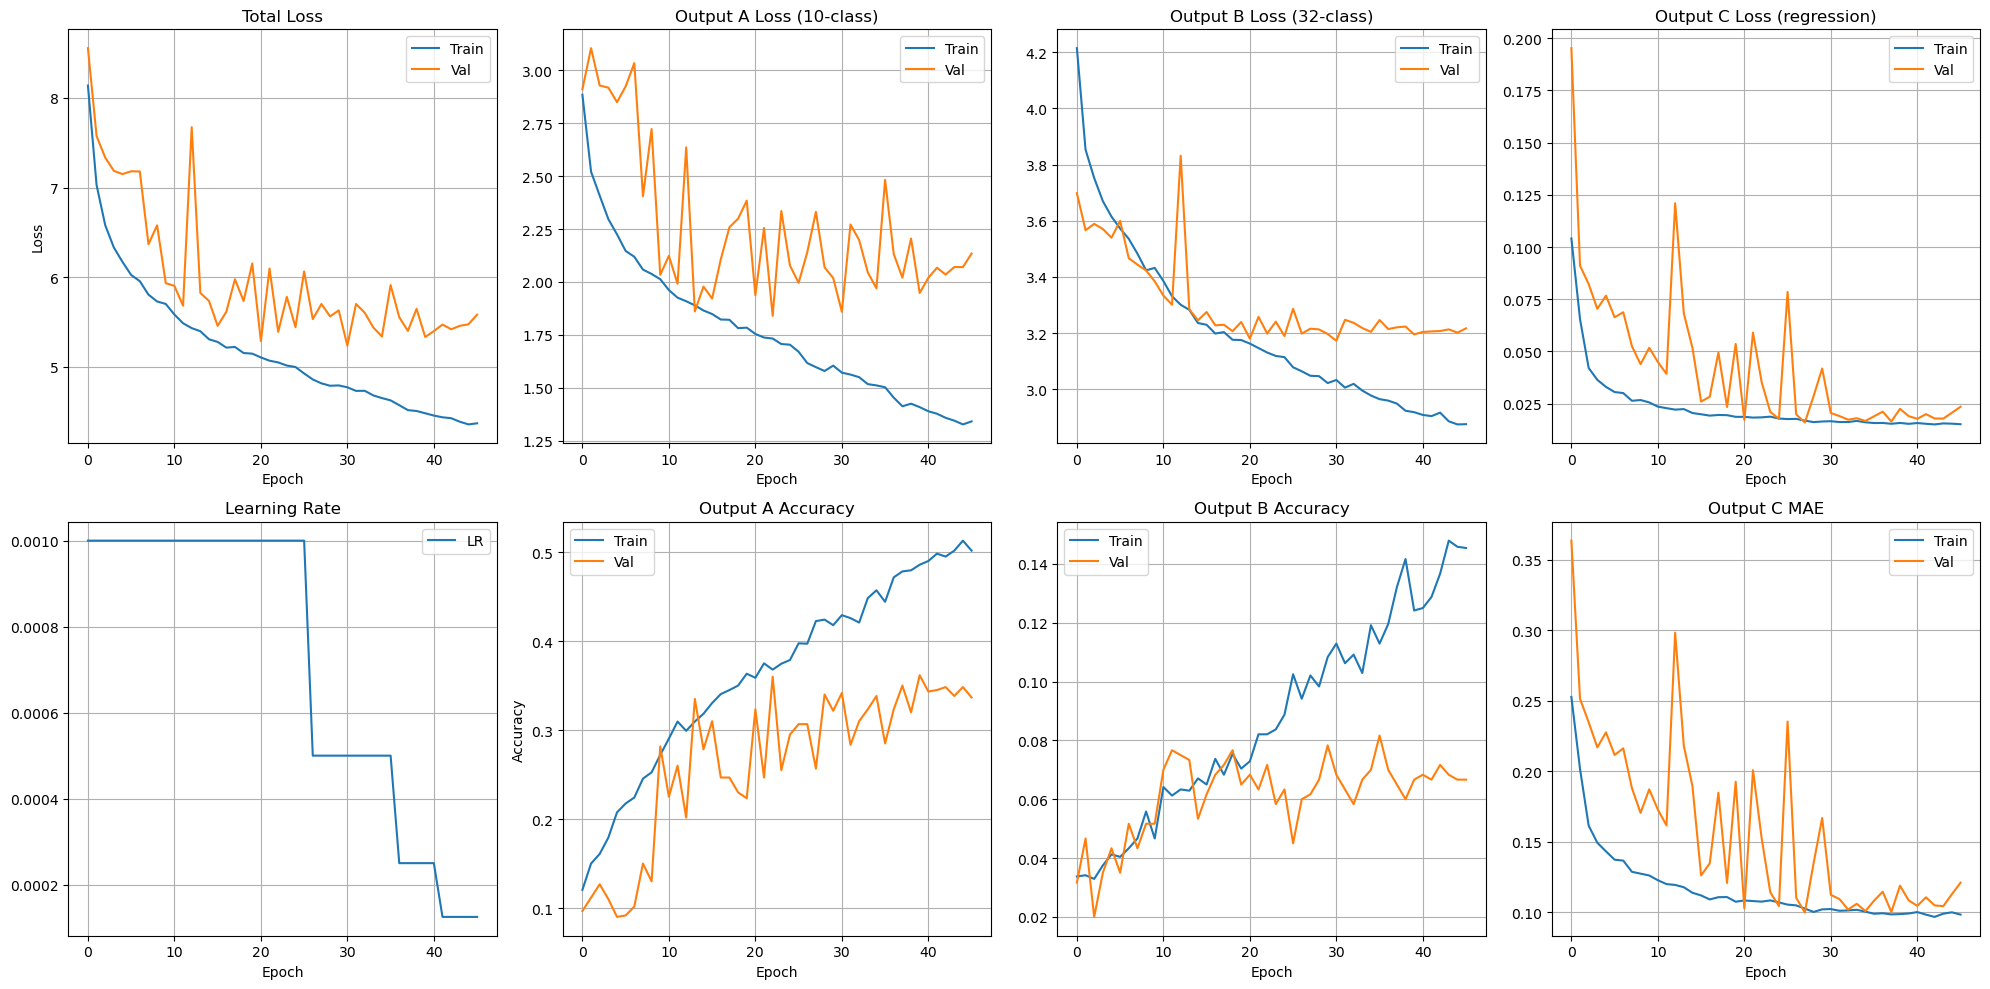

In [15]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'output_a': 'sparse_categorical_crossentropy',
        'output_b': 'sparse_categorical_crossentropy',
        'output_c': 'mse'
    },
    loss_weights={
        'output_a': 1.0,
        'output_b': 1.0,
        'output_c': 10.0  # Higher weight for regression
    },
    metrics={
        'output_a': 'accuracy',
        'output_b': 'accuracy',
        'output_c': 'mae'
    }
)
history = model.fit(
    X_train_norm,
    {
        'output_a': y_train_a,
        'output_b': y_train_b,
        'output_c': y_train_c
    },
    validation_data=(
        X_val_norm,
        {
            'output_a': y_val_a,
            'output_b': y_val_b,
            'output_c': y_val_c
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plot_training_history(history)

### Experiment 1: Baseline + data agumentation (random rotation + random translation)
adding data augmentation is one of the most standard, low-effort ways to test


Model: "baseline_with_aug"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 1) │          0 │ input[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        320 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 8, 64)  │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 4, 4, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4, 4, 128) │          0 │ max_pooling2d_2[

 Total params: 753,419 (2.87 MB)

 Trainable params: 752,267 (2.87 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.7655 - output_a_accuracy: 0.1131 - output_a_loss: 3.1910 - output_b_accuracy: 0.0343 - output_b_loss: 4.3561 - output_c_loss: 0.1218 - output_c_mae: 0.2768
Epoch 1: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 8.1984 - output_a_accuracy: 0.1250 - output_a_loss: 2.9314 - output_b_accuracy: 0.0325 - output_b_loss: 4.1744 - output_c_loss: 0.1093 - output_c_mae: 0.2600 - val_loss: 8.5557 - val_output_a_accuracy: 0.0917 - val_output_a_loss: 2.7450 - val_output_b_accuracy: 0.0350 - val_output_b_loss: 3.5094 - val_output_c_loss: 0.2306 - val_output_c_mae: 0.3996 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 7.3741 - output_a_accuracy: 0.1583 - output_a_loss: 2.5087 - output_b_accuracy: 0.0294 - output_b_loss: 3.9193 - output_c_loss: 0.0946 - output_c_mae: 0.2423
Epoch 2: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss

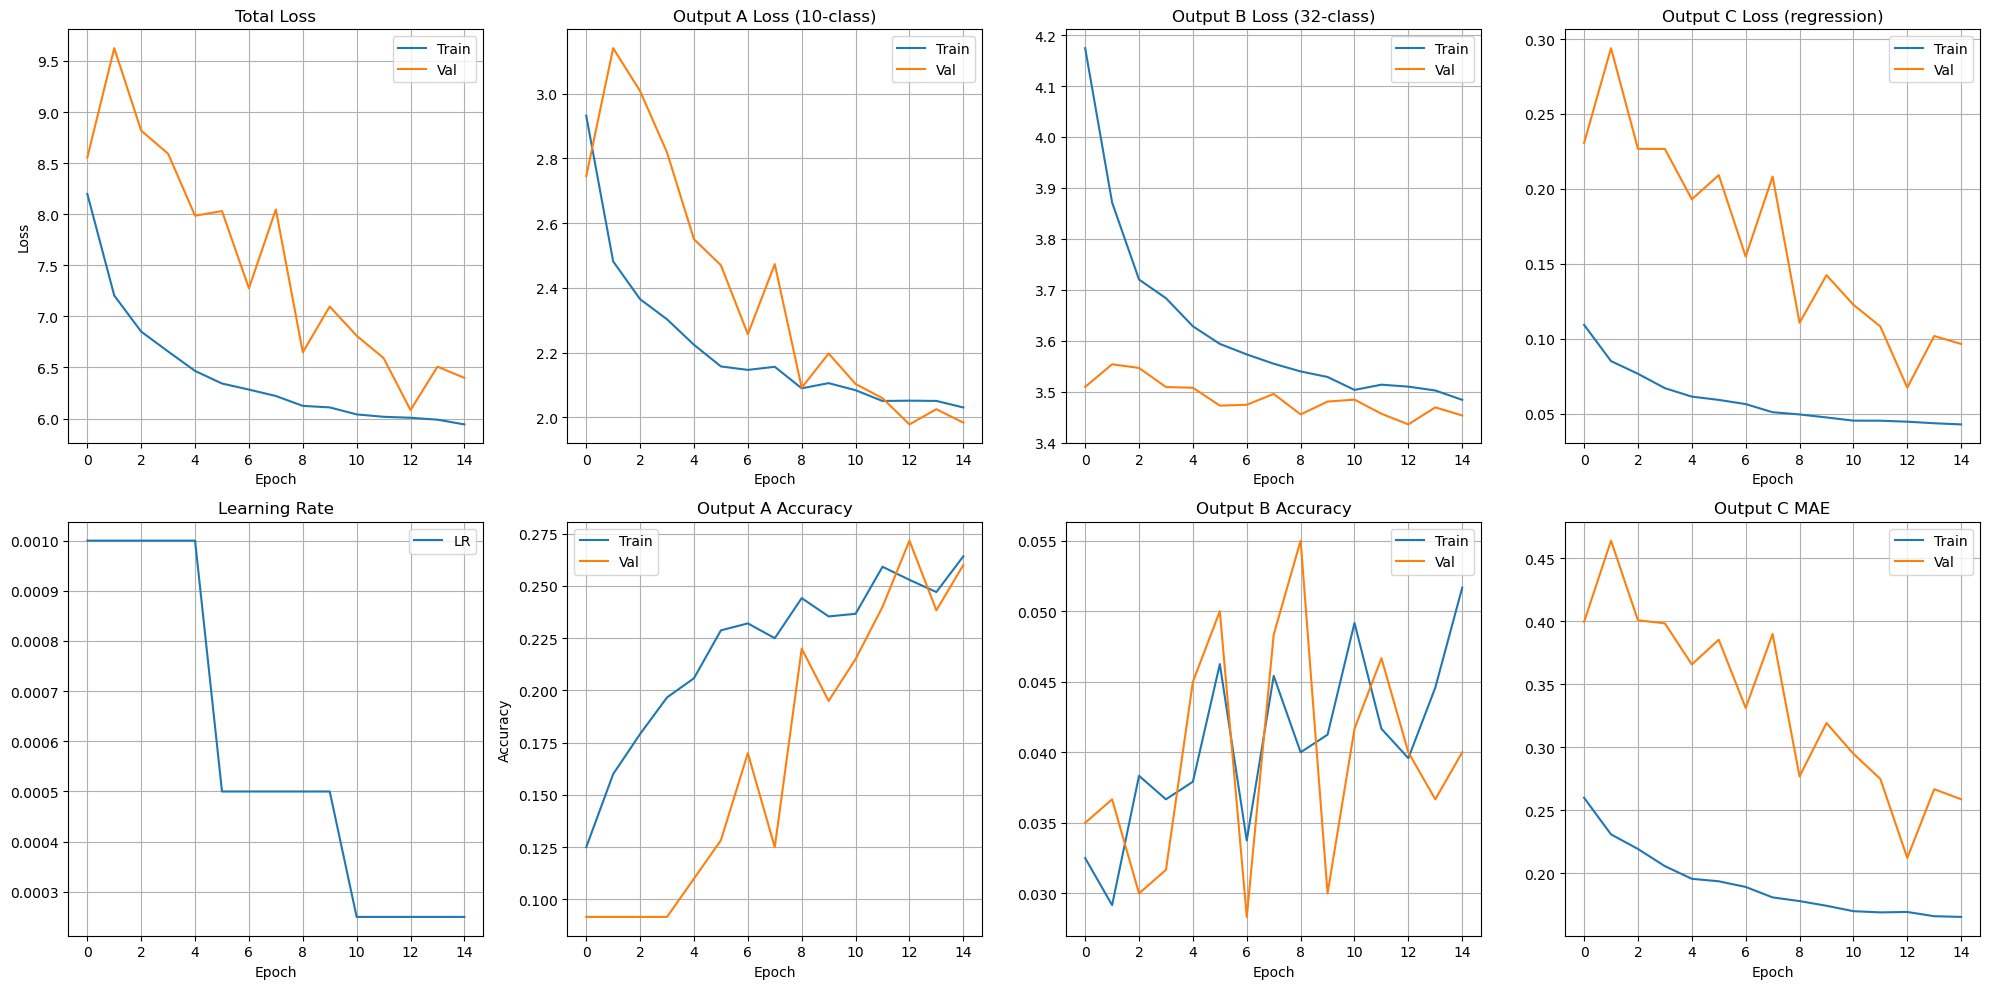

In [16]:

def build_model_with_aug(input_shape=(32, 32, 1), use_flip=False):
    inputs = layers.Input(shape=input_shape, name='input')

    # Data augmentation (only active during training)
    aug_layers = [
        layers.RandomRotation(0.05),                 # ~18 degrees
        layers.RandomTranslation(0.02, 0.02),        # ~3 px shift on 32x32
    ]
    if use_flip:
        aug_layers.append(layers.RandomFlip("horizontal"))

    data_aug = keras.Sequential(aug_layers, name="data_augmentation")
    x = data_aug(inputs)

    # ---- your shared backbone (same style as your current baseline) ----
    # ensure an L2 regularizer is defined for subsequent layers
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Heads
    a = layers.Dense(128, activation='relu')(x)
    a = layers.Dropout(0.3)(a)
    output_a = layers.Dense(10, activation='softmax', name='output_a')(a)

    b = layers.Dense(128, activation='relu')(x)
    b = layers.Dropout(0.3)(b)
    output_b = layers.Dense(32, activation='softmax', name='output_b')(b)

    c = layers.Dense(64, activation='relu')(x)
    c = layers.Dropout(0.3)(c)
    output_c = layers.Dense(1, activation='sigmoid', name='output_c')(c)

    return models.Model(inputs, [output_a, output_b, output_c], name="baseline_with_aug")

# Build the model
model1 = build_model_with_aug(use_flip=False)
model1.summary()

# Compile the model2
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'output_a': 'sparse_categorical_crossentropy',
        'output_b': 'sparse_categorical_crossentropy',
        'output_c': 'mse'
    },
    loss_weights={
        'output_a': 1.0,
        'output_b': 1.0,
        'output_c': 10.0  # Higher weight for regression
    },
    metrics={
        'output_a': 'accuracy',
        'output_b': 'accuracy',
        'output_c': 'mae'
    }
)

#Train the model
history1 = model1.fit(
    X_train_norm,
    {
        'output_a': y_train_a,
        'output_b': y_train_b,
        'output_c': y_train_c
    },
    validation_data=(
        X_val_norm,
        {
            'output_a': y_val_a,
            'output_b': y_val_b,
            'output_c': y_val_c
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plot_training_history(history1)

### Conclusion for experiment 1
`data augmentation` did not improve generalization. <br>
Across all three heads, the augmented model ends up worse on validation (higher losses, lower accuracies, higher MAE), and it also learns more slowly (lower training accuracy), which suggests underfitting / harder optimization rather than helpful regularization.

## Experiment 2: two-stream with late fusion
### Purpose
For the second experiment, I want to combine two different “views” of the same image so the model can learn features that a single backbone might miss. <br>

### Architecture explain
Capture global context + local detail at the same time
- Context stream (downsampled early) is meant to learn coarse, global structure: overall shape, layout, large patterns.
- Fovea stream (center crop, resized) is meant to focus on fine details in the most important region (often where the object is), like edges, small parts, texture.

By concatenating them, the model can use:
- “big picture” signals (context)
- “zoomed-in” signals (fovea)

**Assumption:** the fovea stream is most useful when the discriminative information is near the image center; if objects are not centered, cropping may reduce performance.

Model: "two_stream_arch_only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fovea_crop          │ (None, 16, 16, 1) │          0 │ input[0][0]       │
│ (Cropping2D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_down        │ (None, 16, 16, 1) │          0 │ input[0][0]       │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fovea_resize        │ (None, 32, 32, 1) │          0 │ fovea_crop[0][0]  │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │        320 │ context_down[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │        320 │ fovea_resize[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 8, 8, 32)  │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16, 16,    │          0 │ max_pooling2d_6[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │     18,496 │ dropout_10[0][0]

 Total params: 1,024,619 (3.91 MB)

 Trainable params: 1,022,827 (3.90 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 8.9027 - output_a_accuracy: 0.1132 - output_a_loss: 3.1258 - output_b_accuracy: 0.0244 - output_b_loss: 4.3079 - output_c_loss: 0.1469 - output_c_mae: 0.3039
Epoch 1: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 8.0838 - output_a_accuracy: 0.1367 - output_a_loss: 2.8163 - output_b_accuracy: 0.0279 - output_b_loss: 4.1190 - output_c_loss: 0.1149 - output_c_mae: 0.2668 - val_loss: 9.4138 - val_output_a_accuracy: 0.1033 - val_output_a_loss: 2.7025 - val_output_b_accuracy: 0.0367 - val_output_b_loss: 3.7812 - val_output_c_loss: 0.2927 - val_output_c_mae: 0.4603 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7.0915 - output_a_accuracy: 0.1899 - output_a_loss: 2.3867 - output_b_accuracy: 0.0353 - output_b_loss: 3.8484 - output_c_loss: 0.0856 - output_c_mae: 0.2302
Epoch 2: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss

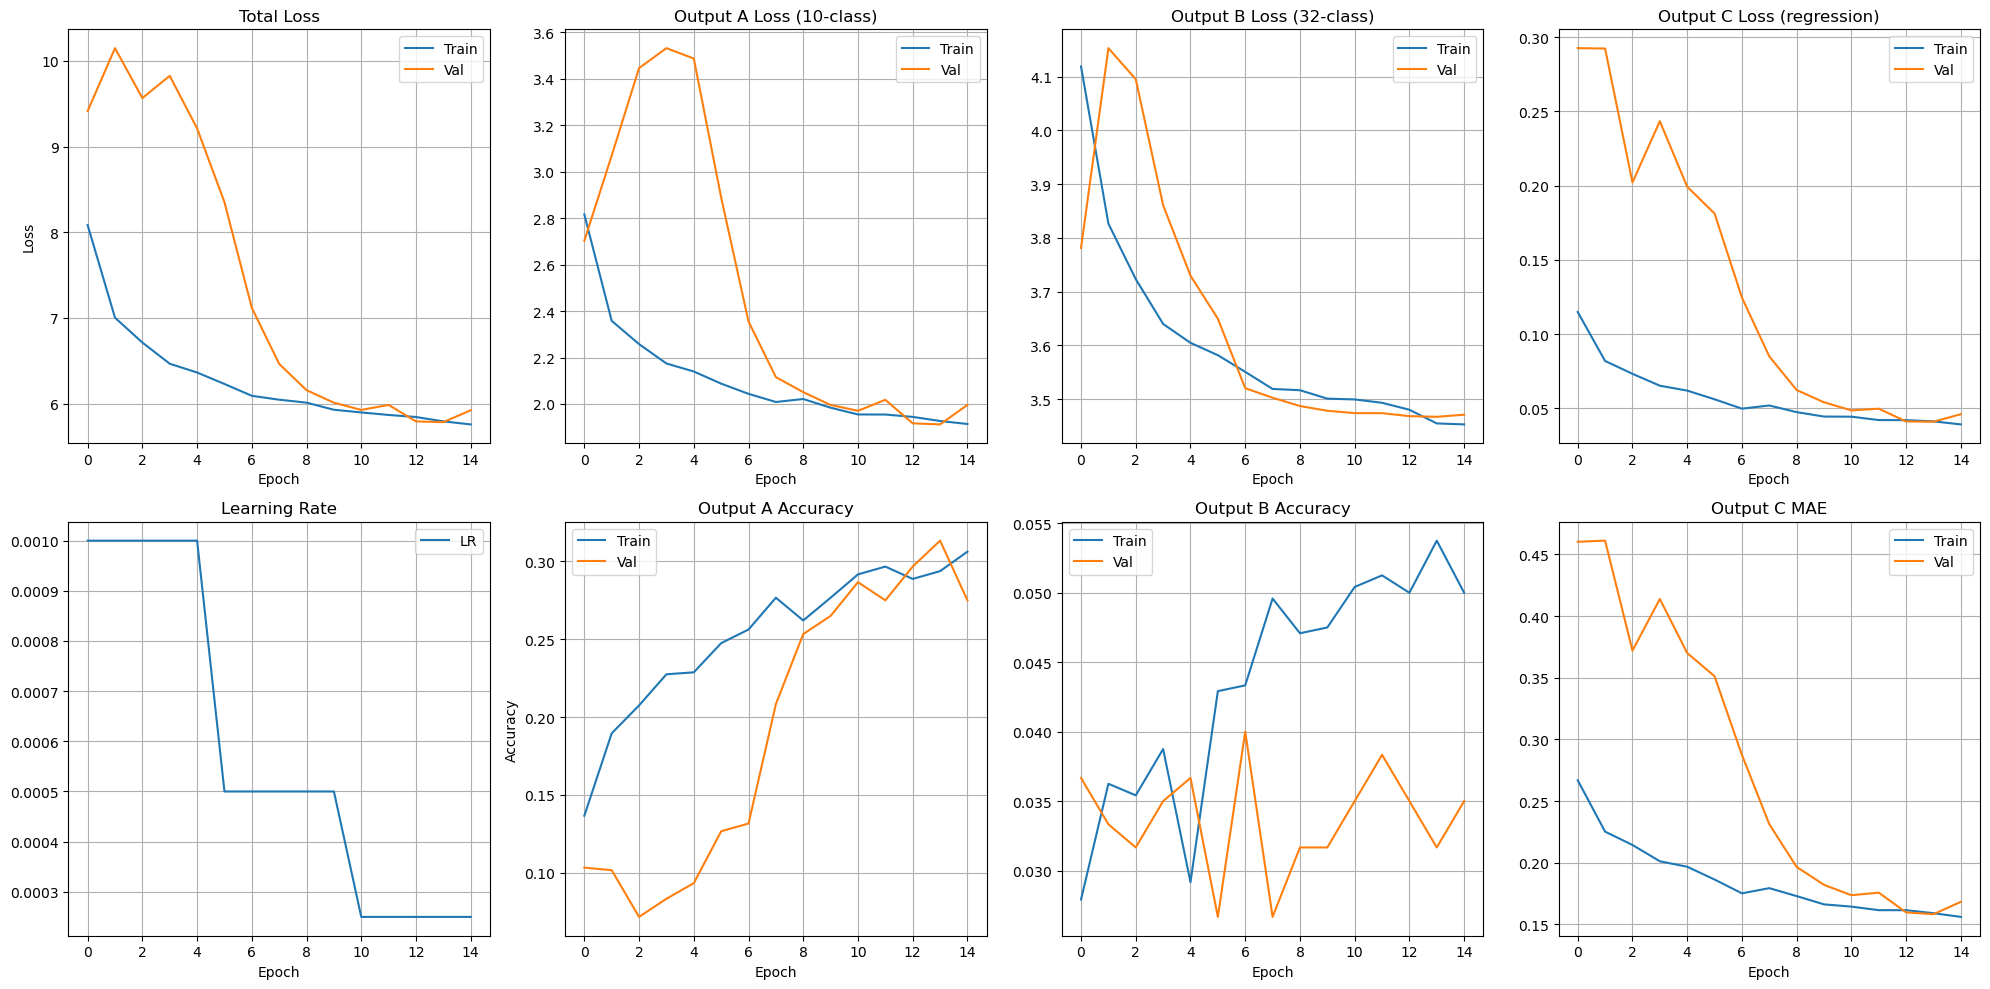

In [17]:
def conv_bn_relu(x, filters, k=3):
    x = layers.Conv2D(filters, k, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def build_two_stream_arch_only(input_shape=(32, 32, 1)):
    inputs = layers.Input(shape=input_shape, name="input")
    x = inputs  # IMPORTANT: no augmentation here (architecture-only experiment)

    # -------------------------
    # Context stream (coarse/global)
    # Downsample early (32->16) to force global view
    context = layers.AveragePooling2D(pool_size=(2, 2), name="context_down")(x)  # (16,16,1)

    # Try to mirror baseline-style blocks (but on lower-res)
    context = conv_bn_relu(context, 32, 3)
    context = conv_bn_relu(context, 32, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.25)(context)

    context = conv_bn_relu(context, 64, 3)
    context = conv_bn_relu(context, 64, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.25)(context)

    context = conv_bn_relu(context, 128, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.30)(context)

    context = layers.Flatten(name="context_flat")(context)

    # -------------------------
    # Fovea stream (center/detail)
    # Crop center 16x16, then resize back to 32x32 so convs see similar scale
    fovea = layers.Cropping2D(cropping=((8, 8), (8, 8)), name="fovea_crop")(x)   # (16,16,1)
    fovea = layers.Resizing(32, 32, name="fovea_resize")(fovea)

    fovea = conv_bn_relu(fovea, 32, 3)
    fovea = conv_bn_relu(fovea, 32, 3)
    fovea = layers.MaxPooling2D()(fovea)
    fovea = layers.Dropout(0.25)(fovea)

    fovea = conv_bn_relu(fovea, 64, 3)
    fovea = conv_bn_relu(fovea, 64, 3)
    fovea = layers.MaxPooling2D()(fovea)
    fovea = layers.Dropout(0.25)(fovea)

    fovea = conv_bn_relu(fovea, 128, 3)
    fovea = layers.MaxPooling2D()(fovea)
    fovea = layers.Dropout(0.30)(fovea)

    fovea = layers.Flatten(name="fovea_flat")(fovea)

    # -------------------------
    # Merge + shared dense (match baseline style)
    merged = layers.Concatenate(name="merge")([context, fovea]) # to combine two backbones
    merged = layers.Dense(256, activation="relu")(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.5)(merged)

    # -------------------------
    # Heads (match baseline)
    a = layers.Dense(128, activation="relu")(merged)
    a = layers.Dropout(0.3)(a)
    output_a = layers.Dense(10, activation="softmax", name="output_a")(a)

    b = layers.Dense(128, activation="relu")(merged)
    b = layers.Dropout(0.3)(b)
    output_b = layers.Dense(32, activation="softmax", name="output_b")(b)

    c = layers.Dense(64, activation="relu")(merged)
    c = layers.Dropout(0.3)(c)
    output_c = layers.Dense(1, activation="sigmoid", name="output_c")(c)  # keep baseline behavior

    return models.Model(inputs, [output_a, output_b, output_c], name="two_stream_arch_only")

# Build
model2_arch_only = build_two_stream_arch_only()
model2_arch_only.summary()

# Compile EXACTLY like baseline (keep these identical for attribution)
model2_arch_only.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "output_a": "sparse_categorical_crossentropy",
        "output_b": "sparse_categorical_crossentropy",
        "output_c": "mse",
    },
    loss_weights={
        "output_a": 1.0,
        "output_b": 1.0,
        "output_c": 10.0,
    },
    metrics={
        "output_a": "accuracy",
        "output_b": "accuracy",
        "output_c": "mae",
    },
)


history2_arch_only = model2_arch_only.fit(
    X_train_norm,
    {
        "output_a": y_train_a, 
        "output_b": y_train_b, 
        "output_c": y_train_c
    },
    validation_data=(
        X_val_norm, 
        {
            "output_a": y_val_a, 
            "output_b": y_val_b, 
            "output_c": y_val_c
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,  
    verbose=1,
)

plot_training_history(history2_arch_only)


## Experiment 3: no-crop two-stream
This model is still a two-stream / dual-branch CNN, but it removes the risky assumption that “the important part is always in the center.”

### Architecture 
1) Two parallel backbones <br>
**Context stream (coarse/global)**
- Starts with AveragePooling2D(2×2) → 32×32 becomes 16×16
- Then goes through several Conv+BN blocks with MaxPooling + Dropout
- Ends with Flatten() to produce a 1D feature vector
**Detail stream (full-res)**
- Uses the original 32×32 input directly (no crop)
- Similar Conv+BN blocks with pooling + dropout
- Ends with Flatten() to produce another 1D feature vector

So you end up with two feature vectors:
- context_features: “big picture”
- detail_features: “fine detail”


2) Late fusion (feature-level merge) 
This concatenates the two vectors into one longer vector. That means the next layers can learn combinations like:
“use context feature X + detail feature Y” for better prediction.
3) Shared trunk + multi-task heads <br>
After merging:
a shared Dense layer learns a joint representation then three task-specific heads:
- A: 10-class softmax
- B: 32-class softmax
- C: regression output (you currently use sigmoid)

Model: "two_stream_no_crop"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_down        │ (None, 16, 16, 1) │          0 │ input[0][0]       │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │        320 │ context_down[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 8, 8, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 8, 8, 32)  │          0 │ max_pooling2d_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 16, 16,    │          0 │ max_pooling2d_12… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 64)  │     18,496 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │     18,496 │ dropout_20[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,024,619 (3.91 MB)

 Trainable params: 1,022,827 (3.90 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8.7638 - output_a_accuracy: 0.1134 - output_a_loss: 3.1500 - output_b_accuracy: 0.0319 - output_b_loss: 4.4114 - output_c_loss: 0.1202 - output_c_mae: 0.2711
Epoch 1: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 8.0172 - output_a_accuracy: 0.1358 - output_a_loss: 2.8245 - output_b_accuracy: 0.0288 - output_b_loss: 4.1688 - output_c_loss: 0.1024 - output_c_mae: 0.2505 - val_loss: 9.4391 - val_output_a_accuracy: 0.0917 - val_output_a_loss: 4.1805 - val_output_b_accuracy: 0.0333 - val_output_b_loss: 3.9059 - val_output_c_loss: 0.1349 - val_output_c_mae: 0.3032 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7.0040 - output_a_accuracy: 0.1507 - output_a_loss: 2.4799 - output_b_accuracy: 0.0288 - output_b_loss: 3.8429 - output_c_loss: 0.0681 - output_c_mae: 0.2049
Epoch 2: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss

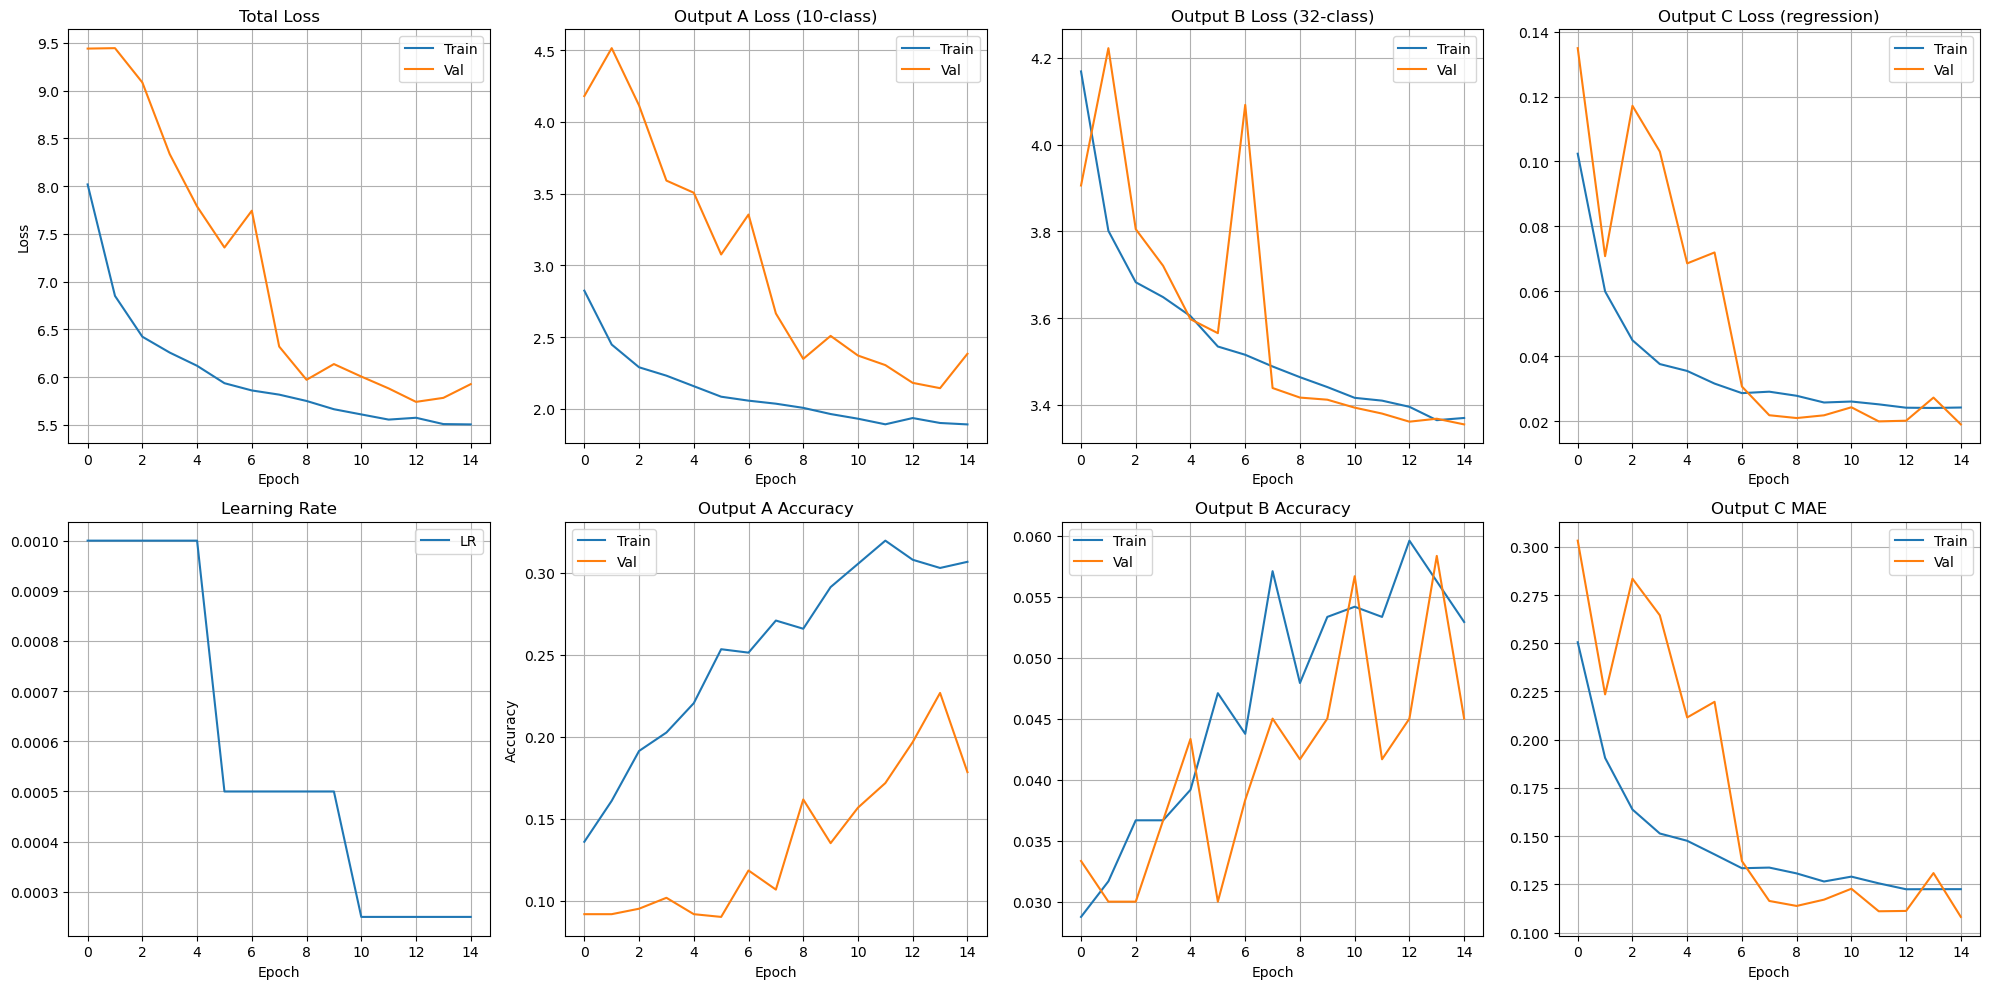

In [18]:

def conv_bn_relu(x, filters, k=3):
    x = layers.Conv2D(filters, k, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def build_two_stream_no_crop(input_shape=(32, 32, 1)):
    inputs = layers.Input(shape=input_shape, name="input")
    x = inputs  # no augmentation (architecture-only)

    # =========================
    # Stream 1: Context (coarse / global)
    # =========================
    context = layers.AveragePooling2D(pool_size=(2, 2), name="context_down")(x)  # 32->16

    context = conv_bn_relu(context, 32, 3)
    context = conv_bn_relu(context, 32, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.25)(context)

    context = conv_bn_relu(context, 64, 3)
    context = conv_bn_relu(context, 64, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.25)(context)

    context = conv_bn_relu(context, 128, 3)
    context = layers.MaxPooling2D()(context)
    context = layers.Dropout(0.30)(context)

    context = layers.Flatten(name="context_flat")(context)

    # =========================
    # Stream 2: Detail (full-res, NO center crop)
    # =========================
    detail = x  # full 32x32 input

    detail = conv_bn_relu(detail, 32, 3)
    detail = conv_bn_relu(detail, 32, 3)
    detail = layers.MaxPooling2D()(detail)
    detail = layers.Dropout(0.25)(detail)

    detail = conv_bn_relu(detail, 64, 3)
    detail = conv_bn_relu(detail, 64, 3)
    detail = layers.MaxPooling2D()(detail)
    detail = layers.Dropout(0.25)(detail)

    detail = conv_bn_relu(detail, 128, 3)
    detail = layers.MaxPooling2D()(detail)
    detail = layers.Dropout(0.30)(detail)

    detail = layers.Flatten(name="detail_flat")(detail)

    # =========================
    # Late fusion + shared trunk
    # =========================
    merged = layers.Concatenate(name="merge")([context, detail])
    merged = layers.Dense(256, activation="relu")(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.5)(merged)

    # =========================
    # Heads (same as baseline)
    # =========================
    a = layers.Dense(128, activation="relu")(merged)
    a = layers.Dropout(0.3)(a)
    output_a = layers.Dense(10, activation="softmax", name="output_a")(a)

    b = layers.Dense(128, activation="relu")(merged)
    b = layers.Dropout(0.3)(b)
    output_b = layers.Dense(32, activation="softmax", name="output_b")(b)

    c = layers.Dense(64, activation="relu")(merged)
    c = layers.Dropout(0.3)(c)
    output_c = layers.Dense(1, activation="sigmoid", name="output_c")(c)

    return models.Model(inputs, [output_a, output_b, output_c], name="two_stream_no_crop")


model_no_crop = build_two_stream_no_crop()
model_no_crop.summary()

model_no_crop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "output_a": "sparse_categorical_crossentropy",
        "output_b": "sparse_categorical_crossentropy",
        "output_c": "mse",
    },
    loss_weights={
        "output_a": 1.0,
        "output_b": 1.0,
        "output_c": 10.0,
    },
    metrics={
        "output_a": "accuracy",
        "output_b": "accuracy",
        "output_c": "mae",
    },
)


history3_no_crop = model_no_crop.fit(
    X_train_norm,
    {
        "output_a": y_train_a, 
        "output_b": y_train_b, 
        "output_c": y_train_c
    },
    validation_data=(
        X_val_norm, 
        {
            "output_a": y_val_a, 
            "output_b": y_val_b, 
            "output_c": y_val_c
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,  
    verbose=1,
)

plot_training_history(history3_no_crop)


## Experiment 4: AlexNet backbone


Model: "alexnetish_arch_only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │        640 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_15… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4096)      │          0 │ max_pooling2d_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 512)       │  2,097,664 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 512)       │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     65,664 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     65,664 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │     32,832 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 128)       │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,229,867 (12.32 MB)

 Trainable params: 3,228,459 (12.32 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 9.5060 - output_a_accuracy: 0.1026 - output_a_loss: 3.2893 - output_b_accuracy: 0.0203 - output_b_loss: 4.8238 - output_c_loss: 0.1393 - output_c_mae: 0.2942
Epoch 1: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 7.4112 - output_a_accuracy: 0.1042 - output_a_loss: 2.6055 - output_b_accuracy: 0.0271 - output_b_loss: 3.9040 - output_c_loss: 0.0902 - output_c_mae: 0.2414 - val_loss: 6.5422 - val_output_a_accuracy: 0.1200 - val_output_a_loss: 2.3015 - val_output_b_accuracy: 0.0317 - val_output_b_loss: 3.4927 - val_output_c_loss: 0.0749 - val_output_c_mae: 0.2339 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 6.4436 - output_a_accuracy: 0.1032 - output_a_loss: 2.3059 - output_b_accuracy: 0.0317 - output_b_loss: 3.4704 - output_c_loss: 0.0667 - output_c_mae: 0.2148
Epoch 2: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - los

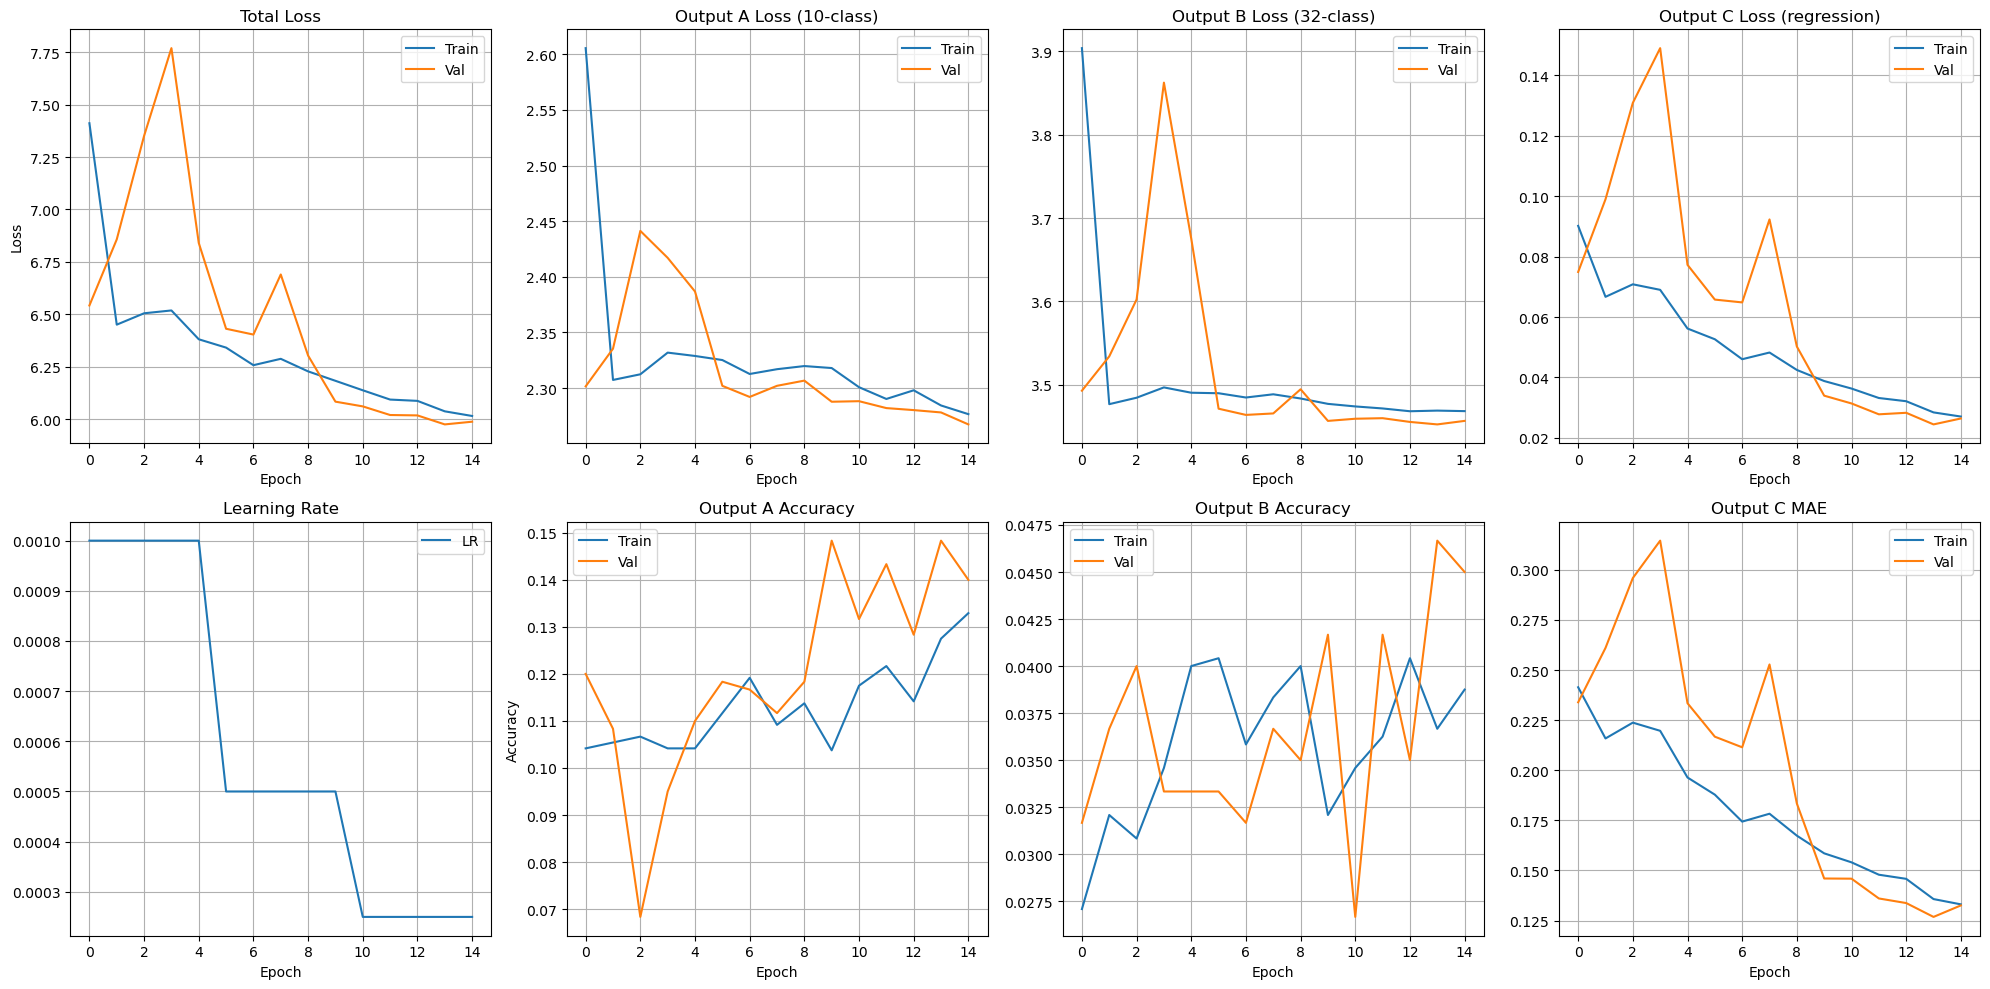

In [19]:
def build_alexnetish(input_shape=(32,32,1)):
    inp = layers.Input(shape=input_shape, name="input")

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)  # match baseline-ish regularization level

    a = layers.Dense(128, activation="relu")(x)
    a = layers.Dropout(0.3)(a)
    output_a = layers.Dense(10, activation="softmax", name="output_a")(a)

    b = layers.Dense(128, activation="relu")(x)
    b = layers.Dropout(0.3)(b)
    output_b = layers.Dense(32, activation="softmax", name="output_b")(b)

    c = layers.Dense(64, activation="relu")(x)
    c = layers.Dropout(0.3)(c)
    output_c = layers.Dense(1, activation="sigmoid", name="output_c")(c)  # keep baseline

    return keras.Model(inp, [output_a, output_b, output_c], name="alexnetish_arch_only")

model4_alexnetish = build_alexnetish()
model4_alexnetish.summary()

model4_alexnetish.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "output_a": "sparse_categorical_crossentropy",
        "output_b": "sparse_categorical_crossentropy",
        "output_c": "mse",
    },
    loss_weights={
        "output_a": 1.0,
        "output_b": 1.0,
        "output_c": 10.0,
    },
    metrics={
        "output_a": "accuracy",
        "output_b": "accuracy",
        "output_c": "mae",
    },
)


history4_alexnetish = model4_alexnetish.fit(
    X_train_norm,
    {
        "output_a": y_train_a, 
        "output_b": y_train_b, 
        "output_c": y_train_c
    },
    validation_data=(
        X_val_norm, 
        {
            "output_a": y_val_a, 
            "output_b": y_val_b, 
            "output_c": y_val_c
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,  
    verbose=1,
)

plot_training_history(history4_alexnetish)


## Experiment 5: early branch

Model: "early_branch_multitask"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 32,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 32,    │      9,248 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 32, 32,    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ bn2[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 16, 16,    │          0 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 16,    │     18,496 │ dropout1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 16, 16,    │        256 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 16, 16,    │     36,928 │ bn3[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 16, 16,    │        256 │ conv4[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 8, 64)  │          0 │ bn4[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 8, 8, 64)  │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ a_conv5 (Conv2D)    │ (None, 8, 8, 128) │     73,856 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_conv5 (Conv2D)    │ (None, 8, 8, 128) │     73,856 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_conv5 (Conv2D)    │ (None, 8, 8, 128) │     73,856 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ a_bn5               │ (None, 8, 8, 128) │        512 │ a_conv5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b_bn5               │ (None, 8, 8, 128) │        512 │ b_conv5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,953,291 (7.45 MB)

 Trainable params: 1,950,603 (7.44 MB)

 Non-trainable params: 2,688 (10.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 8.8876 - output_a_accuracy: 0.1185 - output_a_loss: 3.0287 - output_b_accuracy: 0.0223 - output_b_loss: 4.4804 - output_c_loss: 0.1379 - output_c_mae: 0.2882
Epoch 1: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 8.1499 - output_a_accuracy: 0.1333 - output_a_loss: 2.8496 - output_b_accuracy: 0.0229 - output_b_loss: 4.2114 - output_c_loss: 0.1089 - output_c_mae: 0.2564 - val_loss: 9.0901 - val_output_a_accuracy: 0.1033 - val_output_a_loss: 3.1126 - val_output_b_accuracy: 0.0250 - val_output_b_loss: 3.6367 - val_output_c_loss: 0.2342 - val_output_c_mae: 0.4028 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 7.0997 - output_a_accuracy: 0.1585 - output_a_loss: 2.5140 - output_b_accuracy: 0.0245 - output_b_loss: 3.8768 - output_c_loss: 0.0709 - output_c_mae: 0.2095
Epoch 2: val_loss did not improve from 5.23597
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss

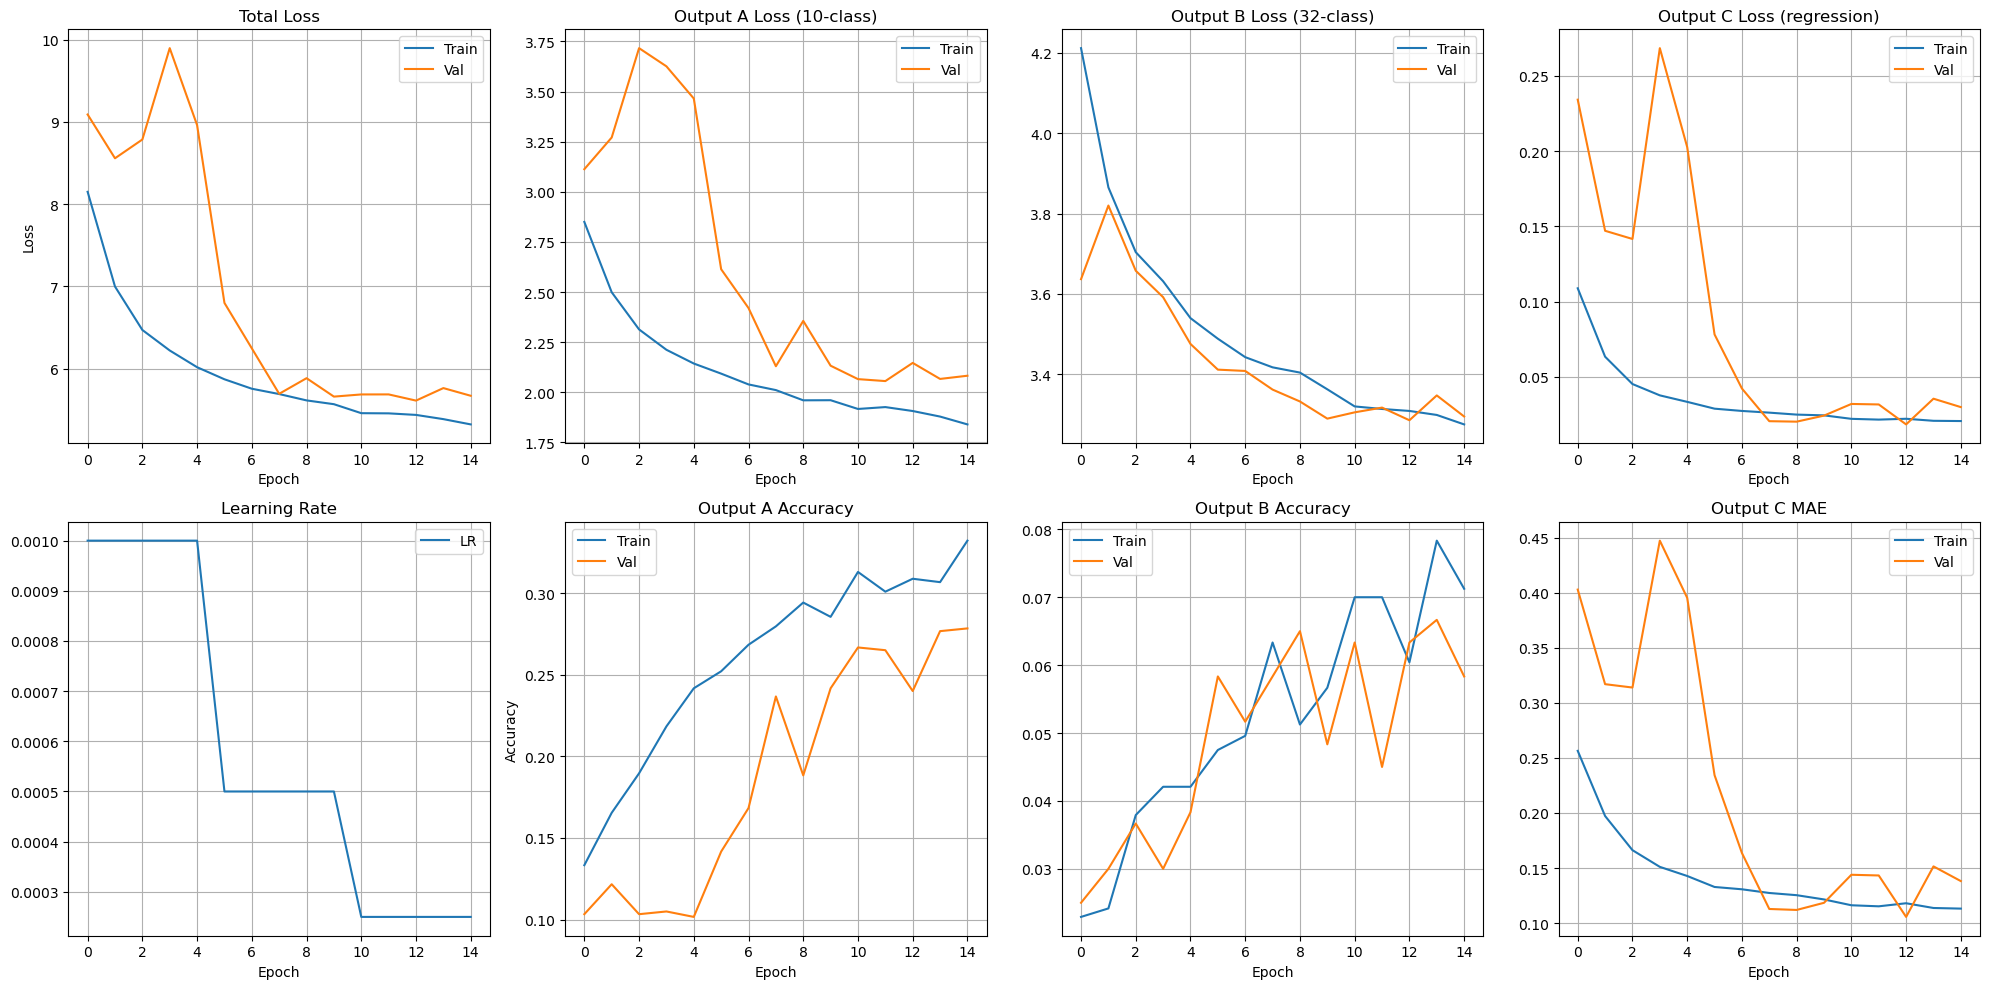

In [20]:


def build_early_branch_multitask(input_shape=(32, 32, 1)):
    """
    Architecture-only ablation vs baseline:
    - Same optimizer/LR, losses, loss_weights (1,1,10), metrics, callbacks
    - No augmentation
    - Early-branch after the 2nd conv block (after pool2 at 8x8)
    - Keep output_c sigmoid (C in [0,1]) to match baseline
    """

    inputs = layers.Input(shape=input_shape, name="input")

    # ===== Shared trunk (MATCH baseline up to pool2) =====
    x = layers.Conv2D(32, 3, activation="relu", padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)          # 32 -> 16
    x = layers.Dropout(0.25, name="dropout1")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    shared = layers.MaxPooling2D(2, name="pool2")(x)     # 16 -> 8
    shared = layers.Dropout(0.25, name="dropout2")(shared)

    # ===== Branch template (MATCH baseline block3 + dense_shared style) =====
    def branch(shared_feat, name_prefix, head_units, out_units, out_activation, head_dropout=0.3):
        z = layers.Conv2D(128, 3, activation="relu", padding="same", name=f"{name_prefix}_conv5")(shared_feat)
        z = layers.BatchNormalization(name=f"{name_prefix}_bn5")(z)
        z = layers.MaxPooling2D(2, name=f"{name_prefix}_pool3")(z)     # 8 -> 4
        z = layers.Dropout(0.30, name=f"{name_prefix}_dropout3")(z)

        z = layers.Flatten(name=f"{name_prefix}_flatten")(z)
        z = layers.Dense(256, activation="relu", name=f"{name_prefix}_dense_shared")(z)
        z = layers.BatchNormalization(name=f"{name_prefix}_bn_shared")(z)
        z = layers.Dropout(0.5, name=f"{name_prefix}_dropout_shared")(z)

        z = layers.Dense(head_units, activation="relu", name=f"{name_prefix}_head_dense1")(z)
        z = layers.Dropout(head_dropout, name=f"{name_prefix}_head_dropout")(z)
        out = layers.Dense(out_units, activation=out_activation, name=f"output_{name_prefix}")(z)
        return out

    # ===== Outputs (same tasks as baseline) =====
    output_a = branch(shared, "a", head_units=128, out_units=10, out_activation="softmax", head_dropout=0.3)
    output_b = branch(shared, "b", head_units=128, out_units=32, out_activation="softmax", head_dropout=0.3)

    # Regression head uses 64 like baseline + sigmoid for [0,1]
    c = layers.Conv2D(128, 3, activation="relu", padding="same", name="c_conv5")(shared)
    c = layers.BatchNormalization(name="c_bn5")(c)
    c = layers.MaxPooling2D(2, name="c_pool3")(c)
    c = layers.Dropout(0.30, name="c_dropout3")(c)
    c = layers.Flatten(name="c_flatten")(c)
    c = layers.Dense(256, activation="relu", name="c_dense_shared")(c)
    c = layers.BatchNormalization(name="c_bn_shared")(c)
    c = layers.Dropout(0.5, name="c_dropout_shared")(c)
    c = layers.Dense(64, activation="relu", name="c_head_dense1")(c)
    c = layers.Dropout(0.3, name="c_head_dropout")(c)
    output_c = layers.Dense(1, activation="sigmoid", name="output_c")(c)

    return models.Model(inputs, [output_a, output_b, output_c], name="early_branch_multitask")

# Build
model_early_branch = build_early_branch_multitask(input_shape=X_train_norm.shape[1:])
model_early_branch.summary()

# Compile EXACTLY like baseline
model_early_branch.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        "output_a": "sparse_categorical_crossentropy",
        "output_b": "sparse_categorical_crossentropy",
        "output_c": "mse",
    },
    loss_weights={
        "output_a": 1.0,
        "output_b": 1.0,
        "output_c": 10.0,
    },
    metrics={
        "output_a": "accuracy",
        "output_b": "accuracy",
        "output_c": "mae",
    },
)

# Train (use the SAME callbacks as baseline: monitor val_loss)
history_early_branch = model_early_branch.fit(
    X_train_norm,
    {"output_a": y_train_a, "output_b": y_train_b, "output_c": y_train_c},
    validation_data=(X_val_norm, {"output_a": y_val_a, "output_b": y_val_b, "output_c": y_val_c}),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

plot_training_history(history_early_branch)


---

## OPTION A: LOAD PRE-TRAINED MODEL

Use this section if you want to load an already-trained model.

In [21]:
# OPTION A: Load saved model
LOAD_MODEL = False  # Set to True to load, False to train from scratch

if LOAD_MODEL:
    model = keras.models.load_model('model_groupId.h5')
    print("Model loaded successfully!")
    print(f"\nModel summary:")
    model.summary()

---

## OPTION B: TRAIN MODEL FROM SCRATCH

Use this section to train the model.

In [22]:
# OPTION B: Train the model
TRAIN_MODEL = False  # Set to True to train, False to skip

if TRAIN_MODEL:
    print("Starting training...\n")
    
    history = model.fit(
        X_train_norm,
        {
            'output_a': y_train_a,
            'output_b': y_train_b,
            'output_c': y_train_c
        },
        validation_data=(
            X_val_norm,
            {
                'output_a': y_val_a,
                'output_b': y_val_b,
                'output_c': y_val_c
            }
        ),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    print("\nTraining completed!")

In [23]:
# Plot training history
if TRAIN_MODEL:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Total loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Output A - Loss
    axes[0, 1].plot(history.history['output_a_loss'], label='Train')
    axes[0, 1].plot(history.history['val_output_a_loss'], label='Val')
    axes[0, 1].set_title('Output A Loss (10-class)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Output B - Loss
    axes[0, 2].plot(history.history['output_b_loss'], label='Train')
    axes[0, 2].plot(history.history['val_output_b_loss'], label='Val')
    axes[0, 2].set_title('Output B Loss (32-class)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Output C - Loss
    axes[0, 3].plot(history.history['output_c_loss'], label='Train')
    axes[0, 3].plot(history.history['val_output_c_loss'], label='Val')
    axes[0, 3].set_title('Output C Loss (regression)')
    axes[0, 3].set_xlabel('Epoch')
    axes[0, 3].legend()
    axes[0, 3].grid(True)
    
    # Output A - Accuracy
    axes[1, 1].plot(history.history['output_a_accuracy'], label='Train')
    axes[1, 1].plot(history.history['val_output_a_accuracy'], label='Val')
    axes[1, 1].set_title('Output A Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Output B - Accuracy
    axes[1, 2].plot(history.history['output_b_accuracy'], label='Train')
    axes[1, 2].plot(history.history['val_output_b_accuracy'], label='Val')
    axes[1, 2].set_title('Output B Accuracy')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
    
    # Output C - MAE
    axes[1, 3].plot(history.history['output_c_mae'], label='Train')
    axes[1, 3].plot(history.history['val_output_c_mae'], label='Val')
    axes[1, 3].set_title('Output C MAE')
    axes[1, 3].set_xlabel('Epoch')
    axes[1, 3].legend()
    axes[1, 3].grid(True)
    
    # Learning rate (if available)
    axes[1, 0].axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. Evaluation and Results

Now we evaluate the model on the validation set and analyze performance.

In [24]:
# Get predictions on validation set
predictions = model.predict(X_val_norm)
pred_a, pred_b, pred_c = predictions

# Convert predictions to final format
pred_a_class = np.argmax(pred_a, axis=1)
pred_b_class = np.argmax(pred_b, axis=1)
pred_c_value = pred_c.squeeze()

print("Prediction shapes:")
print(f"  pred_a_class: {pred_a_class.shape}")
print(f"  pred_b_class: {pred_b_class.shape}")
print(f"  pred_c_value: {pred_c_value.shape}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Prediction shapes:
  pred_a_class: (600,)
  pred_b_class: (600,)
  pred_c_value: (600,)


In [25]:
# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix

# Target A metrics
acc_a = accuracy_score(y_val_a, pred_a_class)
print("=" * 60)
print("TARGET A (10-class classification)")
print("=" * 60)
print(f"Accuracy: {acc_a:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_a, pred_a_class))

# Target B metrics
acc_b = accuracy_score(y_val_b, pred_b_class)
print("\n" + "=" * 60)
print("TARGET B (32-class classification)")
print("=" * 60)
print(f"Accuracy: {acc_b:.4f}")
print("\nClassification Report (first 10 classes):")
print(classification_report(y_val_b, pred_b_class, labels=list(range(10))))

# Target C metrics
mse_c = mean_squared_error(y_val_c, pred_c_value)
mae_c = mean_absolute_error(y_val_c, pred_c_value)
print("\n" + "=" * 60)
print("TARGET C (regression)")
print("=" * 60)
print(f"MSE: {mse_c:.6f}")
print(f"RMSE: {np.sqrt(mse_c):.6f}")
print(f"MAE: {mae_c:.6f}")

TARGET A (10-class classification)
Accuracy: 0.3417

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.24      0.30        59
           1       0.42      0.53      0.47        62
           2       0.22      0.23      0.22        62
           3       0.35      0.19      0.24        64
           4       0.30      0.40      0.35        62
           5       0.32      0.22      0.26        59
           6       0.28      0.67      0.39        55
           7       0.54      0.24      0.33        58
           8       0.38      0.43      0.40        61
           9       0.42      0.29      0.35        58

    accuracy                           0.34       600
   macro avg       0.37      0.34      0.33       600
weighted avg       0.36      0.34      0.33       600


TARGET B (32-class classification)
Accuracy: 0.0683

Classification Report (first 10 classes):
              precision    recall  f1-score   support

           0  

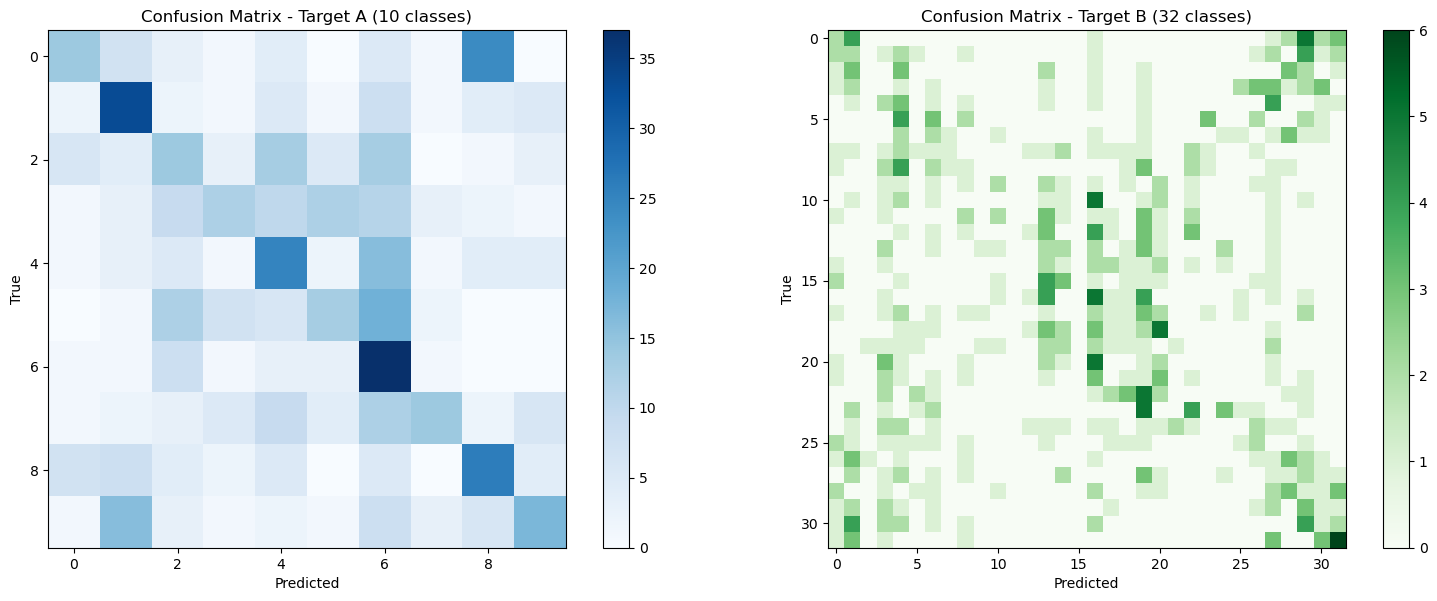

In [26]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix for Target A
cm_a = confusion_matrix(y_val_a, pred_a_class)
im1 = axes[0].imshow(cm_a, cmap='Blues')
axes[0].set_title('Confusion Matrix - Target A (10 classes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.colorbar(im1, ax=axes[0])

# Confusion matrix for Target B (show subset)
cm_b = confusion_matrix(y_val_b, pred_b_class)
im2 = axes[1].imshow(cm_b, cmap='Greens')
axes[1].set_title('Confusion Matrix - Target B (32 classes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

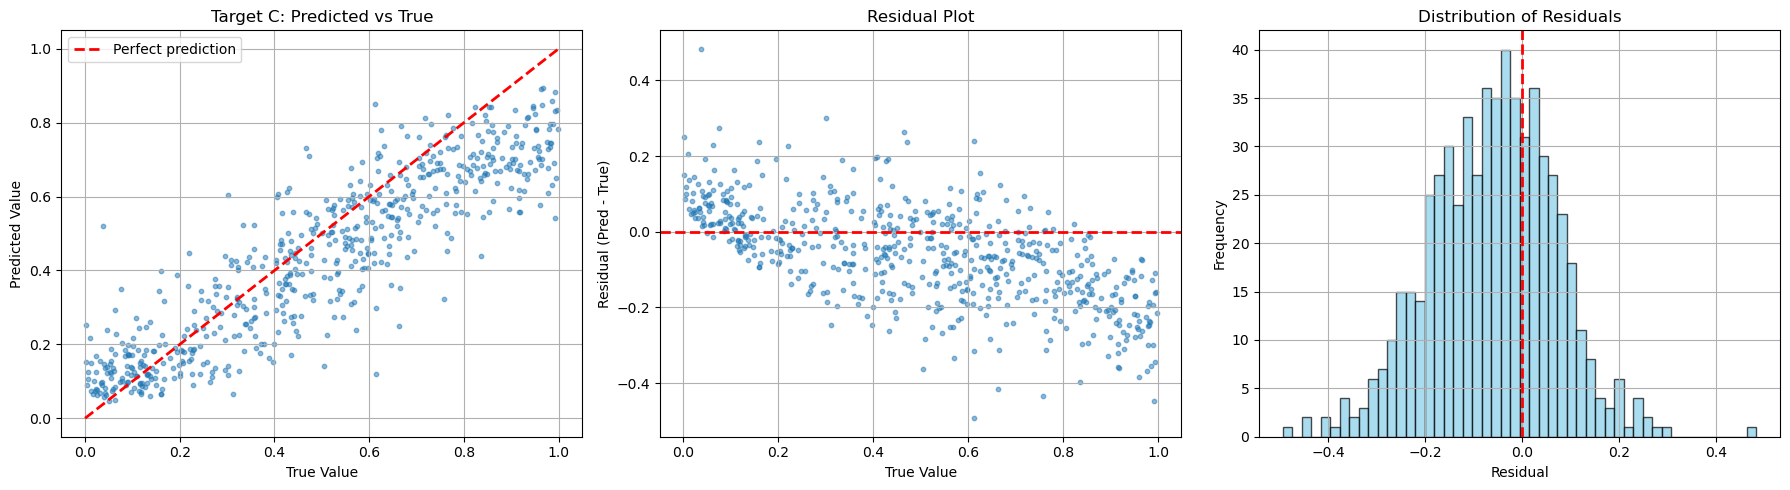

In [27]:
# Regression analysis for Target C
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot: predicted vs actual
axes[0].scatter(y_val_c, pred_c_value, alpha=0.5, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Target C: Predicted vs True')
axes[0].legend()
axes[0].grid(True)

# Residuals
residuals = pred_c_value - y_val_c
axes[1].scatter(y_val_c, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('True Value')
axes[1].set_ylabel('Residual (Pred - True)')
axes[1].set_title('Residual Plot')
axes[1].grid(True)

# Histogram of residuals
axes[2].hist(residuals, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 9. Create Prediction Function

This is the required `predict_fn` that takes raw input and returns predictions in the correct format.

In [28]:
def predict_fn(X_input):
    """
    Prediction function for the model.
    
    Args:
        X_input: numpy array of shape (N, 32, 32)
    
    Returns:
        predictions: numpy array of shape (N, 3) where:
            - column 0: Target A predictions (0-9)
            - column 1: Target B predictions (0-31)
            - column 2: Target C predictions (0-1)
    """
    # Normalize input using training statistics
    X_normalized = (X_input - mean) / std
    
    # Add channel dimension
    X_normalized = X_normalized[..., np.newaxis]
    
    # Get predictions
    pred_a, pred_b, pred_c = model.predict(X_normalized, verbose=0)
    
    # Convert to final format
    pred_a_class = np.argmax(pred_a, axis=1).astype(np.float32)
    pred_b_class = np.argmax(pred_b, axis=1).astype(np.float32)
    pred_c_value = pred_c.squeeze().astype(np.float32)
    
    # Stack predictions
    predictions = np.column_stack([pred_a_class, pred_b_class, pred_c_value])
    
    return predictions

# Test the function
test_input = X[:5]  # First 5 samples
test_output = predict_fn(test_input)

print("Test predictions:")
print(test_output)
print(f"\nOutput shape: {test_output.shape}")
print(f"\nTrue values:")
print(y[:5])

Test predictions:
[[ 6.          3.          0.4615447 ]
 [ 6.         23.          0.64786893]
 [ 6.          1.          0.42566153]
 [ 7.         12.          0.4612626 ]
 [ 6.          1.          0.42776436]]

Output shape: (5, 3)

True values:
[[ 7.          1.          0.47756684]
 [ 5.         23.          0.8644116 ]
 [ 3.         27.          0.4516205 ]
 [ 9.         24.          0.5948042 ]
 [ 4.         29.          0.40230054]]


## 10. Reflection and Future Improvements

### What Worked Well
- Multi-head architecture successfully handles three independent tasks
- Shared feature extractor learns useful representations for all outputs
- Proper train/validation split with stratification
- Regularization (Dropout, BatchNorm) helps prevent overfitting

### Limitations
1. **Limited data**: 3000 samples is small for deep learning
2. **Loss balancing**: Finding optimal loss weights requires experimentation
3. **Architecture depth**: Might benefit from deeper networks if more data available
4. **Target B challenge**: 32 classes with ~90 samples each is difficult

### Possible Improvements
1. **Data augmentation**: Random rotations, flips, translations to increase effective dataset size
2. **Loss weight tuning**: Grid search or dynamic weighting strategies
3. **Architecture experiments**:
   - Residual connections (ResNet-style)
   - Attention mechanisms
   - Different activation functions (LeakyReLU, ELU)
4. **Ensemble methods**: Train multiple models and average predictions
5. **Advanced regularization**: MixUp, CutMix, label smoothing
6. **Transfer learning**: If similar datasets exist
7. **Uncertainty quantification**: Monte Carlo dropout for prediction confidence

### Experimental Results Summary
*(To be filled after experiments)*

| Experiment | Target A Acc | Target B Acc | Target C MAE | Notes |
|-----------|--------------|--------------|--------------|-------|
| Baseline  | TBD | TBD | TBD | Current model |
| Augmentation | TBD | TBD | TBD | + rotation/flip |
| Loss weights | TBD | TBD | TBD | Different ratios |
| Deeper CNN | TBD | TBD | TBD | Extra conv layers |

## 11. Final Model Save

Save the final model for submission.

In [29]:
# Save the final model
model.save('model_groupId.h5')
print("Model saved as 'model_groupId.h5'")

# Verify it can be loaded
loaded_model = keras.models.load_model('model_groupId.h5')
print("\nModel successfully loaded and verified!")

Model saved as 'model_groupId.h5'


ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

---

## Submission Checklist

- [ ] Notebook runs end-to-end without errors
- [ ] Both Option A (load) and Option B (train) work correctly
- [ ] `predict_fn` function produces correct output format
- [ ] All required sections included with markdown explanations
- [ ] Model saved as `model_groupId.h5`
- [ ] Academic honesty statement included
- [ ] Figures are clearly labeled
- [ ] Code is well-commented
- [ ] Group members listed

**Ready for submission!**